# Clasificación de papas nativas - EfficientNetB0 con dataset combinado experimental

Notebook experimental para entrenar y evaluar usando el dataset combinado completo mediante una división 70/15/15. Este archivo mezcla todas las imágenes disponibles dentro del flujo de entrenamiento y evaluación, pero conserva trazabilidad interna del origen para evitar errores metodológicos y revisar fugas de datos.

Para una tesis o publicación, no se debe presentar contenido generado/aumentado como si fuera captura real original; este notebook queda como experimento complementario al protocolo principal.

Los artefactos se guardan en `OUTPUT_DIR`: distribución del split, auditorías, métricas globales, métricas por origen, matrices de confusión, modelo entrenado y exportación ONNX.

In [1]:
# Dependencias ligeras. No se actualizan pandas/matplotlib para evitar conflictos en Kaggle.
!pip -q install seaborn scikit-learn pydot

In [2]:
# Imports de TensorFlow, métricas y visualización
import os
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import mixed_precision
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

if tf.config.list_physical_devices("GPU"):
    mixed_precision.set_global_policy("mixed_float16")
    try:
        for gpu in tf.config.list_physical_devices("GPU"):
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print("Memory growth no configurado:", exc)

strategy = tf.distribute.MirroredStrategy() if len(tf.config.list_physical_devices("GPU")) > 1 else tf.distribute.get_strategy()
print("Réplicas sincronizadas:", strategy.num_replicas_in_sync)

os.environ["PYTHONHASHSEED"] = str(SEED) if "SEED" in globals() else "123"

2026-04-30 23:05:46.780526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777590347.022821      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777590347.091415      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777590347.600221      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777590347.600308      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777590347.600312      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Réplicas sincronizadas: 2


I0000 00:00:1777590372.886952      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777590372.893020      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# Configuración Kaggle, dataset aumentado y manifest anti-fuga
import os, re, json, random, shutil, zipfile, hashlib, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display

SEED = 123
random.seed(SEED)
np.random.seed(SEED)

TAG = "cnn_dataset_combinado"
FAST_KAGGLE_RUN = True
SAVE_MODEL_PLOTS = True
EXPORT_ONNX = False
RUN_STRICT_NEAR_DUP_AUDIT = False

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".jfif"}
MANIFEST_FILENAME = "split_manifest_70_15_15_visual_clusters_v2.csv"
# Protocolo de división para tesis y experimentación.
# thesis_real_eval: sintéticas solo en train; val/test quedan reales.
# mixed_synthetic_eval: redivide reales+sintéticas en train/val/test para experimento complementario.
SPLIT_PROTOCOL = "mixed_synthetic_eval"
VALID_SPLIT_PROTOCOLS = {"thesis_real_eval", "mixed_synthetic_eval"}
if SPLIT_PROTOCOL not in VALID_SPLIT_PROTOCOLS:
    raise ValueError(f"SPLIT_PROTOCOL debe ser uno de {sorted(VALID_SPLIT_PROTOCOLS)}")
MIXED_SPLIT_RATIOS = {"train": 0.70, "val": 0.15, "test": 0.15}
SYNTHETIC_MARKERS = ("__sd_img2img_synthetic_1000",)
KAGGLE_INPUT_DIR = Path("/kaggle/input")
KAGGLE_WORKING_DIR = Path("/kaggle/working")
IS_KAGGLE = KAGGLE_INPUT_DIR.exists() and KAGGLE_WORKING_DIR.exists()

if IS_KAGGLE:
    WORK_ROOT = KAGGLE_WORKING_DIR / "tomas_training"
    EXTRACT_ROOT = KAGGLE_WORKING_DIR / "tomas_extracted"
else:
    WORK_ROOT = Path.cwd() / "tomas_training_local"
    EXTRACT_ROOT = Path.cwd()

OUTPUT_DIR = WORK_ROOT / f"outputs_{TAG}"
MODEL_DIR = OUTPUT_DIR / "models"
for p in [WORK_ROOT, OUTPUT_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)


def count_images(root):
    root = Path(root)
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS)


def extract_tomas_zip_if_needed():
    if not IS_KAGGLE:
        return [Path.cwd()]
    zip_candidates = sorted(KAGGLE_INPUT_DIR.rglob("tomas.zip"))
    if not zip_candidates:
        return [KAGGLE_INPUT_DIR]
    zip_path = zip_candidates[0]
    marker = EXTRACT_ROOT / ".extract_done"
    if not marker.exists() or marker.read_text(encoding="utf-8") != str(zip_path):
        if EXTRACT_ROOT.exists():
            shutil.rmtree(EXTRACT_ROOT)
        EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)
        print(f"Extrayendo {zip_path} en {EXTRACT_ROOT} ...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(EXTRACT_ROOT)
        marker.write_text(str(zip_path), encoding="utf-8")
    return [EXTRACT_ROOT, KAGGLE_INPUT_DIR]


# Rutas preferidas según tu dataset actual en Kaggle.
# Kaggle puede mostrar el nombre como DATASET_VARIEDADES, pero el path real puede variar en mayúsculas/minúsculas.
KAGGLE_TOMAS_ROOT_HINTS = [
    Path("/kaggle/input/DATASET_VARIEDADES/tomas"),
    Path("/kaggle/input/dataset-variedades/tomas"),
    Path("/kaggle/input/dataset_variedades/tomas"),
]


def find_tomas_roots(search_roots):
    candidates = []
    for hint in KAGGLE_TOMAS_ROOT_HINTS:
        if (hint / "dataset").exists() and count_images(hint / "dataset") > 0:
            candidates.append(hint)
    for search_root in search_roots:
        for dataset_dir in Path(search_root).rglob("dataset"):
            if dataset_dir.is_dir() and count_images(dataset_dir) > 0:
                candidates.append(dataset_dir.parent)
    unique = []
    seen = set()
    for candidate in candidates:
        key = str(candidate.resolve()) if candidate.exists() else str(candidate)
        if key not in seen:
            seen.add(key)
            unique.append(candidate)
    return unique


def find_dataset_and_manifest():
    roots = extract_tomas_zip_if_needed()
    tomas_roots = find_tomas_roots(roots)
    if not tomas_roots:
        raise FileNotFoundError("No se encontró una estructura tomas/dataset dentro de tomas.zip o /kaggle/input.")

    scored_roots = []
    for tomas_root in tomas_roots:
        dataset_dir = tomas_root / "dataset"
        n_images = count_images(dataset_dir)
        score = n_images
        if tomas_root.name.lower() == "tomas":
            score += 100000
        if "DATASET_VARIEDADES" in str(tomas_root) or "dataset-variedades" in str(tomas_root).lower():
            score += 50000
        scored_roots.append((score, tomas_root, dataset_dir))
    scored_roots = sorted(scored_roots, key=lambda item: item[0], reverse=True)
    _, tomas_root, dataset_dir = scored_roots[0]

    preferred_manifest = tomas_root / MANIFEST_FILENAME
    if preferred_manifest.exists():
        manifest_path = preferred_manifest
    else:
        manifest_candidates = list(tomas_root.rglob(MANIFEST_FILENAME))
        if not manifest_candidates:
            for search_root in roots:
                manifest_candidates.extend(Path(search_root).rglob(MANIFEST_FILENAME))
        manifest_path = sorted(manifest_candidates, key=lambda p: ("backup" in p.name.lower(), len(str(p))))[0] if manifest_candidates else None

    print("Raíz tomas seleccionada:", tomas_root)
    print("Candidatos tomas detectados:")
    for _, candidate_root, candidate_dataset in scored_roots[:5]:
        print(" -", candidate_root, "| imágenes:", count_images(candidate_dataset))
    return dataset_dir, manifest_path

DATASET_DIR, FOUND_MANIFEST_PATH = find_dataset_and_manifest()
SPLIT_MANIFEST_PATH = WORK_ROOT / MANIFEST_FILENAME
if FOUND_MANIFEST_PATH and not SPLIT_MANIFEST_PATH.exists():
    shutil.copy2(FOUND_MANIFEST_PATH, SPLIT_MANIFEST_PATH)
elif FOUND_MANIFEST_PATH and FOUND_MANIFEST_PATH != SPLIT_MANIFEST_PATH:
    shutil.copy2(FOUND_MANIFEST_PATH, SPLIT_MANIFEST_PATH)

print("Entorno:", "Kaggle" if IS_KAGGLE else "Local")
print("DATASET_DIR:", DATASET_DIR)
print("Manifest fuente:", FOUND_MANIFEST_PATH)
print("Manifest editable:", SPLIT_MANIFEST_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Imágenes detectadas:", count_images(DATASET_DIR))


def normalize_key(text):
    text = unicodedata.normalize("NFKD", str(text))
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r"[^A-Z0-9]+", "", text.upper())


def rel_after_dataset(path_value):
    parts = Path(str(path_value)).parts
    if "dataset" in parts:
        idx = parts.index("dataset")
        return Path(*parts[idx + 1:]).as_posix()
    return "/".join(parts[-2:])


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def dhash_file(path, hash_size=16):
    resample = getattr(getattr(Image, "Resampling", Image), "LANCZOS")
    with Image.open(path) as img:
        img = img.convert("L").resize((hash_size + 1, hash_size), resample)
        pixels = np.asarray(img, dtype=np.int16)
    diff = pixels[:, 1:] > pixels[:, :-1]
    value = 0
    for bit in diff.flatten():
        value = (value << 1) | int(bit)
    return f"{value:0{(hash_size * hash_size + 3) // 4}x}"


def hamming_hex(a, b):
    return (int(str(a), 16) ^ int(str(b), 16)).bit_count()


def collect_image_index(dataset_dir):
    class_dirs = sorted([p for p in Path(dataset_dir).iterdir() if p.is_dir() and not p.name.startswith(".")], key=lambda p: p.name)
    class_names = [p.name for p in class_dirs]
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    rows = []
    for class_dir in class_dirs:
        for path in sorted(class_dir.rglob("*"), key=lambda p: str(p)):
            if path.is_file() and path.suffix.lower() in VALID_EXTENSIONS:
                rows.append({"path": str(path), "class_name": class_dir.name, "label": class_to_idx[class_dir.name]})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No se encontraron imágenes válidas en {dataset_dir}")
    return df, class_names, class_to_idx

all_df, class_names, class_to_idx = collect_image_index(DATASET_DIR)
NUM_CLASSES = len(class_names)
if NUM_CLASSES != 7:
    print(f"Advertencia: se detectaron {NUM_CLASSES} clases, se esperaban 7.")


def is_synthetic_path(path):
    text = str(path).replace("\\", "/")
    return any(marker in text for marker in SYNTHETIC_MARKERS)


def parse_bool_value(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if pd.isna(value):
        return False
    return str(value).strip().lower() in {"1", "true", "t", "yes", "y", "si", "sí"}


def stable_text_hash(value, length=16):
    return hashlib.sha1(str(value).encode("utf-8", errors="ignore")).hexdigest()[:length]


all_df["is_synthetic"] = all_df["path"].map(is_synthetic_path)
all_df["source_path"] = np.where(all_df["is_synthetic"], "", all_df["path"])
all_df["source_group_id"] = ""

path_meta = all_df.set_index("path")[["class_name", "label"]].to_dict("index")
all_df["rel_key"] = all_df["path"].map(rel_after_dataset)
all_df["norm_class"] = all_df["class_name"].map(normalize_key)
all_df["file_name"] = all_df["path"].map(lambda p: Path(p).name)
all_df["norm_file"] = all_df["file_name"].map(normalize_key)
rel_map = dict(zip(all_df["rel_key"], all_df["path"]))
class_file_map = dict(zip(zip(all_df["norm_class"], all_df["file_name"]), all_df["path"]))
class_normfile_map = dict(zip(zip(all_df["norm_class"], all_df["norm_file"]), all_df["path"]))


def remap_manifest_row(row):
    original = str(row["path"])
    if Path(original).exists():
        return original
    rel = rel_after_dataset(original)
    if rel in rel_map:
        return rel_map[rel]
    class_key = normalize_key(row.get("class_name", ""))
    file_name = Path(original).name
    if (class_key, file_name) in class_file_map:
        return class_file_map[(class_key, file_name)]
    norm_file = normalize_key(file_name)
    if (class_key, norm_file) in class_normfile_map:
        return class_normfile_map[(class_key, norm_file)]
    return str(DATASET_DIR / rel)


def build_fallback_manifest():
    print("No se encontró manifest válido. Se creará split base: reales 70/15/15 y sintéticas a train.")
    rows = []
    for class_name, class_df in all_df.groupby("class_name", sort=True):
        class_df = class_df.copy().sample(frac=1.0, random_state=SEED).reset_index(drop=True)
        synthetic_mask = class_df["path"].map(is_synthetic_path)
        real_df = class_df[~synthetic_mask].copy().reset_index(drop=True)
        synth_df = class_df[synthetic_mask].copy().reset_index(drop=True)
        n = len(real_df)
        n_train = int(round(n * 0.70))
        n_val = int(round(n * 0.15))
        real_df["split"] = "test"
        real_df.loc[: n_train - 1, "split"] = "train"
        real_df.loc[n_train : n_train + n_val - 1, "split"] = "val"
        synth_df["split"] = "train"
        rows.append(pd.concat([real_df, synth_df], ignore_index=True))
    manifest = pd.concat(rows, ignore_index=True)
    manifest["is_synthetic"] = manifest["path"].map(is_synthetic_path)
    manifest["source_path"] = np.where(manifest["is_synthetic"], "", manifest["path"])
    manifest["source_group_id"] = ""
    manifest["sha256"] = [sha256_file(p) for p in manifest["path"]]
    manifest["visual_hash"] = [dhash_file(p) for p in manifest["path"]]
    manifest["group_id"] = manifest["class_name"] + "__" + manifest["split"] + "__" + np.arange(len(manifest)).astype(str)
    return manifest

if SPLIT_MANIFEST_PATH.exists():
    manifest_df = pd.read_csv(SPLIT_MANIFEST_PATH)
else:
    manifest_df = build_fallback_manifest()

manifest_df["original_path"] = manifest_df["path"].astype(str)
manifest_df["path"] = manifest_df.apply(remap_manifest_row, axis=1)
manifest_df["path_exists"] = manifest_df["path"].map(lambda p: Path(p).exists())
missing_paths = manifest_df[~manifest_df["path_exists"]]
if not missing_paths.empty:
    missing_report = OUTPUT_DIR / "manifest_paths_no_encontrados.csv"
    missing_paths.to_csv(missing_report, index=False, encoding="utf-8")
    raise FileNotFoundError(f"Hay rutas del manifest no encontradas. Revisa {missing_report}")

manifest_df["class_name_original"] = manifest_df.get("class_name", "")
manifest_df["label_original"] = manifest_df.get("label", -1)
manifest_df["class_name"] = manifest_df["path"].map(lambda p: path_meta[p]["class_name"])
manifest_df["label"] = manifest_df["path"].map(lambda p: path_meta[p]["label"])

# Agrega imágenes que estén en el dataset pero no en el manifest; por defecto quedan en train.
manifest_paths = set(manifest_df["path"])
extra_df = all_df[~all_df["path"].isin(manifest_paths)].copy()
if not extra_df.empty:
    print(f"Agregando {len(extra_df)} imágenes ausentes del manifest como train.")
    extra_df["split"] = "train"
    extra_df["original_path"] = extra_df["path"]
    extra_df["class_name_original"] = extra_df["class_name"]
    extra_df["label_original"] = extra_df["label"]
    extra_df["sha256"] = [sha256_file(p) for p in extra_df["path"]]
    extra_df["visual_hash"] = [dhash_file(p) for p in extra_df["path"]]
    extra_df["group_id"] = extra_df["class_name"] + "__extra_train__" + np.arange(len(extra_df)).astype(str)
    extra_df["is_synthetic"] = extra_df["path"].map(is_synthetic_path)
    extra_df["source_path"] = np.where(extra_df["is_synthetic"], "", extra_df["path"])
    extra_df["source_group_id"] = ""
    manifest_df = pd.concat([manifest_df, extra_df], ignore_index=True, sort=False)

for col in ["sha256", "visual_hash", "group_id", "source_path", "source_group_id"]:
    if col not in manifest_df.columns:
        manifest_df[col] = ""

manifest_df["path"] = manifest_df["path"].astype(str)
manifest_df["is_synthetic_path"] = manifest_df["path"].map(is_synthetic_path)
if "is_synthetic" in manifest_df.columns:
    manifest_df["is_synthetic"] = manifest_df["is_synthetic"].map(parse_bool_value) | manifest_df["is_synthetic_path"]
else:
    manifest_df["is_synthetic"] = manifest_df["is_synthetic_path"]
manifest_df["source_path"] = manifest_df["source_path"].fillna("").astype(str)
manifest_df["source_group_id"] = manifest_df["source_group_id"].fillna("").astype(str)


def remap_source_path_value(row):
    value = str(row.get("source_path", "")).strip()
    if not value:
        return ""
    if Path(value).exists():
        return value
    candidate = remap_manifest_row({"path": value, "class_name": row.get("class_name", "")})
    return candidate if Path(candidate).exists() else value


manifest_df["source_path"] = manifest_df.apply(remap_source_path_value, axis=1)
real_missing_source = (~manifest_df["is_synthetic"]) & manifest_df["source_path"].str.strip().eq("")
manifest_df.loc[real_missing_source, "source_path"] = manifest_df.loc[real_missing_source, "path"]
real_missing_source_group = (~manifest_df["is_synthetic"]) & manifest_df["source_group_id"].str.strip().eq("")
manifest_df.loc[real_missing_source_group, "source_group_id"] = manifest_df.loc[real_missing_source_group, "group_id"].astype(str)

source_path_to_group = manifest_df.loc[~manifest_df["is_synthetic"]].drop_duplicates("path").set_index("path")["group_id"].to_dict()
synth_known_source = manifest_df["is_synthetic"] & manifest_df["source_group_id"].str.strip().eq("") & manifest_df["source_path"].isin(source_path_to_group)
manifest_df.loc[synth_known_source, "source_group_id"] = manifest_df.loc[synth_known_source, "source_path"].map(source_path_to_group).astype(str)

synth_with_source_group = manifest_df["is_synthetic"] & manifest_df["source_group_id"].str.strip().ne("")
manifest_df.loc[synth_with_source_group, "group_id"] = manifest_df.loc[synth_with_source_group, "source_group_id"].astype(str)
synth_with_source_path = manifest_df["is_synthetic"] & manifest_df["source_group_id"].str.strip().eq("") & manifest_df["source_path"].str.strip().ne("")
manifest_df.loc[synth_with_source_path, "group_id"] = manifest_df.loc[synth_with_source_path].apply(
    lambda row: f"{row['class_name']}__source_path__{stable_text_hash(row['source_path'])}", axis=1
)

empty_sha = manifest_df["sha256"].isna() | (manifest_df["sha256"].astype(str) == "")
empty_vh = manifest_df["visual_hash"].isna() | (manifest_df["visual_hash"].astype(str) == "")
empty_group = manifest_df["group_id"].isna() | (manifest_df["group_id"].astype(str) == "")
if empty_sha.any():
    manifest_df.loc[empty_sha, "sha256"] = [sha256_file(p) for p in manifest_df.loc[empty_sha, "path"]]
if empty_vh.any():
    manifest_df.loc[empty_vh, "visual_hash"] = [dhash_file(p) for p in manifest_df.loc[empty_vh, "path"]]
if empty_group.any():
    manifest_df.loc[empty_group, "group_id"] = manifest_df.loc[empty_group, "class_name"] + "__generated_group__" + manifest_df.loc[empty_group].index.astype(str)

if "split_original" not in manifest_df.columns:
    manifest_df["split_original"] = manifest_df.get("split", "train")
manifest_df["split_original"] = manifest_df["split_original"].fillna("train").astype(str).str.lower()
manifest_df.loc[~manifest_df["split_original"].isin(["train", "val", "test"]), "split_original"] = "train"


def make_split_group_key(row):
    if bool(row["is_synthetic"]):
        if str(row.get("source_group_id", "")).strip():
            key = f"group__{row['source_group_id']}"
        elif str(row.get("source_path", "")).strip():
            key = f"source_path__{stable_text_hash(row['source_path'])}"
        else:
            key = f"synthetic__{row['group_id']}"
    else:
        key = f"group__{row['group_id']}"
    return f"{row['class_name']}__{key}"


def apply_thesis_real_eval_split(df):
    result = df.copy()
    result["split"] = result["split_original"]
    result.loc[result["is_synthetic"], "split"] = "train"
    return result


def target_split_counts(n, ratios):
    n_train = int(round(n * ratios["train"]))
    n_val = int(round(n * ratios["val"]))
    n_test = max(0, n - n_train - n_val)
    return {"train": n_train, "val": n_val, "test": n_test}


def apply_mixed_synthetic_eval_split(df):
    result_parts = []
    for class_name, class_df in df.groupby("class_name", sort=True):
        class_df = class_df.copy()
        targets = target_split_counts(len(class_df), MIXED_SPLIT_RATIOS)
        groups = class_df.groupby("split_group_key", sort=False).size().reset_index(name="n")
        groups = groups.sample(frac=1.0, random_state=SEED + int(class_df["label"].iloc[0])).reset_index(drop=True)
        counts = {"train": 0, "val": 0, "test": 0}
        assignments = {}
        for _, group_row in groups.iterrows():
            group_size = int(group_row["n"])
            def score(split_name):
                target = max(targets[split_name], 1)
                return (targets[split_name] - counts[split_name]) / target
            selected_split = max(["train", "val", "test"], key=score)
            assignments[group_row["split_group_key"]] = selected_split
            counts[selected_split] += group_size
        class_df["split"] = class_df["split_group_key"].map(assignments)
        print(f"Split mixto {class_name}: objetivo={targets}, obtenido={counts}")
        result_parts.append(class_df)
    return pd.concat(result_parts, ignore_index=True)


manifest_df["split_group_key"] = manifest_df.apply(make_split_group_key, axis=1)
if SPLIT_PROTOCOL == "thesis_real_eval":
    manifest_df = apply_thesis_real_eval_split(manifest_df)
elif SPLIT_PROTOCOL == "mixed_synthetic_eval":
    manifest_df = apply_mixed_synthetic_eval_split(manifest_df)
else:
    raise ValueError(f"SPLIT_PROTOCOL no soportado: {SPLIT_PROTOCOL}")

manifest_df = manifest_df.drop(columns=["path_exists", "is_synthetic_path"], errors="ignore")
manifest_df.to_csv(SPLIT_MANIFEST_PATH, index=False, encoding="utf-8")
manifest_df.to_csv(OUTPUT_DIR / f"split_manifest_{TAG}_kaggle_remapeado.csv", index=False, encoding="utf-8")
manifest_df.to_csv(OUTPUT_DIR / f"split_manifest_{TAG}_{SPLIT_PROTOCOL}.csv", index=False, encoding="utf-8")

train_df = manifest_df[manifest_df["split"] == "train"].sort_values("path").reset_index(drop=True)
val_df = manifest_df[manifest_df["split"] == "val"].sort_values("path").reset_index(drop=True)
test_df = manifest_df[manifest_df["split"] == "test"].sort_values("path").reset_index(drop=True)

origin_split_report = manifest_df.assign(origin=np.where(manifest_df["is_synthetic"], "synthetic", "real"))
reporte_split_protocol = origin_split_report.groupby(["class_name", "split", "origin"], observed=True).size().reset_index(name="n_images")
reporte_split_protocol.to_csv(OUTPUT_DIR / "reporte_split_protocol.csv", index=False, encoding="utf-8")
conteo_real_sintetico_por_split = origin_split_report.pivot_table(
    index="class_name", columns=["split", "origin"], values="path", aggfunc="count", fill_value=0
)
conteo_real_sintetico_por_split.to_csv(OUTPUT_DIR / "conteo_real_sintetico_por_split.csv", encoding="utf-8")
split_protocol_config = {
    "split_protocol": SPLIT_PROTOCOL,
    "description": "thesis_real_eval mantiene val/test reales; mixed_synthetic_eval mezcla reales y sintéticas como experimento complementario.",
    "mixed_split_ratios": MIXED_SPLIT_RATIOS,
    "synthetic_markers": list(SYNTHETIC_MARKERS),
    "n_total": int(len(manifest_df)),
    "n_train": int(len(train_df)),
    "n_val": int(len(val_df)),
    "n_test": int(len(test_df)),
    "n_synthetic_train": int(train_df["is_synthetic"].sum()),
    "n_synthetic_val": int(val_df["is_synthetic"].sum()),
    "n_synthetic_test": int(test_df["is_synthetic"].sum()),
}
(OUTPUT_DIR / "split_protocol_config.json").write_text(json.dumps(split_protocol_config, ensure_ascii=False, indent=2), encoding="utf-8")

distribution_df = pd.concat([
    train_df.assign(split_name="train"),
    val_df.assign(split_name="val"),
    test_df.assign(split_name="test"),
]).pivot_table(index="class_name", columns="split_name", values="path", aggfunc="count", fill_value=0)

(OUTPUT_DIR / "classes.txt").write_text("\n".join(class_names) + "\n", encoding="utf-8")
distribution_df.to_csv(OUTPUT_DIR / f"distribucion_splits_{TAG}.csv", encoding="utf-8")

print(f"Clases ({NUM_CLASSES}):")
for idx, name in enumerate(class_names):
    print(f"  {idx}: {name}")
print(f"Tamaños: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
display(distribution_df)

Raíz tomas seleccionada: /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas
Candidatos tomas detectados:
 - /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas | imágenes: 7000
Entorno: Kaggle
DATASET_DIR: /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas/dataset
Manifest fuente: /kaggle/input/datasets/josluisquispelen/dataset-variedades/tomas/split_manifest_70_15_15_visual_clusters_v2.csv
Manifest editable: /kaggle/working/tomas_training/split_manifest_70_15_15_visual_clusters_v2.csv
OUTPUT_DIR: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado
Imágenes detectadas: 7000
Split mixto 1 VARIEDAD - PUKA_ÑATA: objetivo={'train': 700, 'val': 150, 'test': 150}, obtenido={'train': 698, 'val': 151, 'test': 151}
Split mixto 2 VARIDAD - TOROPA_WAQRAN: objetivo={'train': 700, 'val': 150, 'test': 150}, obtenido={'train': 699, 'val': 151, 'test': 150}
Split mixto 3 VARIEDAD - PUMAPA_MAKIN: objetivo={'train': 700, 'val': 150, 'test': 150}, obtenid

split_name,test,train,val
class_name,,,
1 VARIEDAD - PUKA_ÑATA,151,698,151
2 VARIDAD - TOROPA_WAQRAN,150,699,151
3 VARIEDAD - PUMAPA_MAKIN,150,698,152
4 VARIDAD - PUTISA,150,699,151
5 VARIEDAD - YURAQ_LEGUAS,150,700,150
6 VARIEDAD - YURAQ_JEWICHO,150,698,152
7 VARIEDAD - CANUTILLO,146,682,172


## Vista previa científica del dataset

Esta sección documenta el estado real del dataset antes de entrenar: distribución por clase, distribución por split, proporción de imágenes reales/sintéticas, tamaños de imagen y muestras visuales. Estos artefactos se guardan en `OUTPUT_DIR` para usarlos en la tesis y para verificar que el entrenamiento se realiza con datos correctamente organizados.

Resumen general del dataset


,num_classes,total_images_manifest,train_images,val_images,test_images,real_images,synthetic_images,all_paths_exist
0,7,7000,4874,1079,1047,2800,4200,True


Distribución por clase, split y origen


,test,train,val,real,synthetic,total
class_name,,,,,,
1 VARIEDAD - PUKA_ÑATA,151,698,151,400,600,2000
2 VARIDAD - TOROPA_WAQRAN,150,699,151,400,600,2000
3 VARIEDAD - PUMAPA_MAKIN,150,698,152,400,600,2000
4 VARIDAD - PUTISA,150,699,151,400,600,2000
5 VARIEDAD - YURAQ_LEGUAS,150,700,150,400,600,2000
6 VARIEDAD - YURAQ_JEWICHO,150,698,152,400,600,2000
7 VARIEDAD - CANUTILLO,146,682,172,400,600,2000


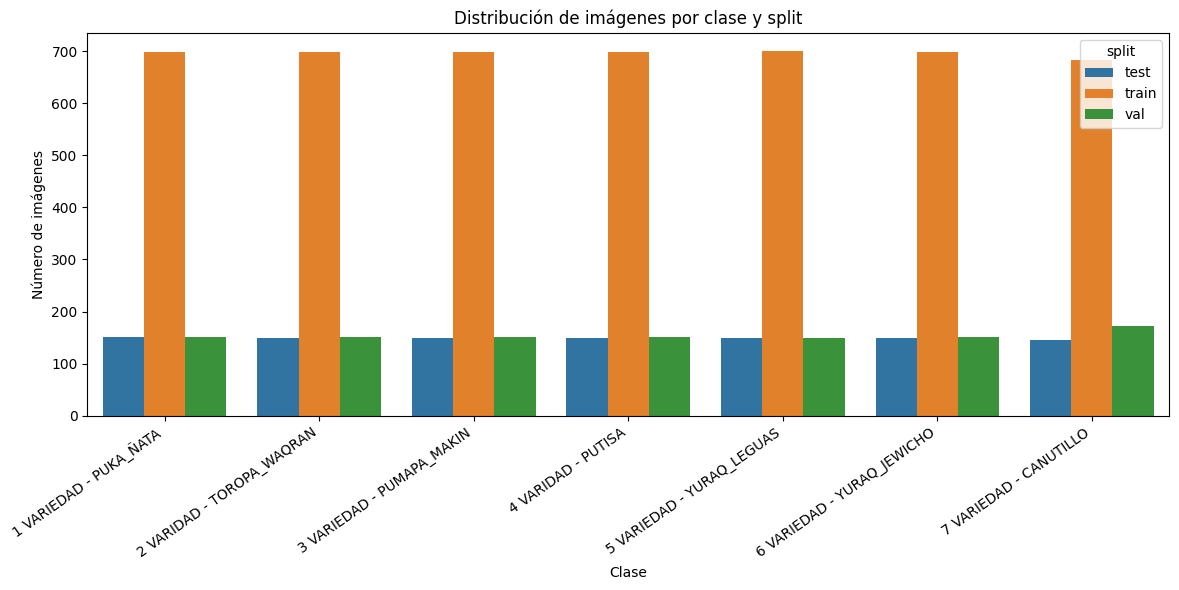

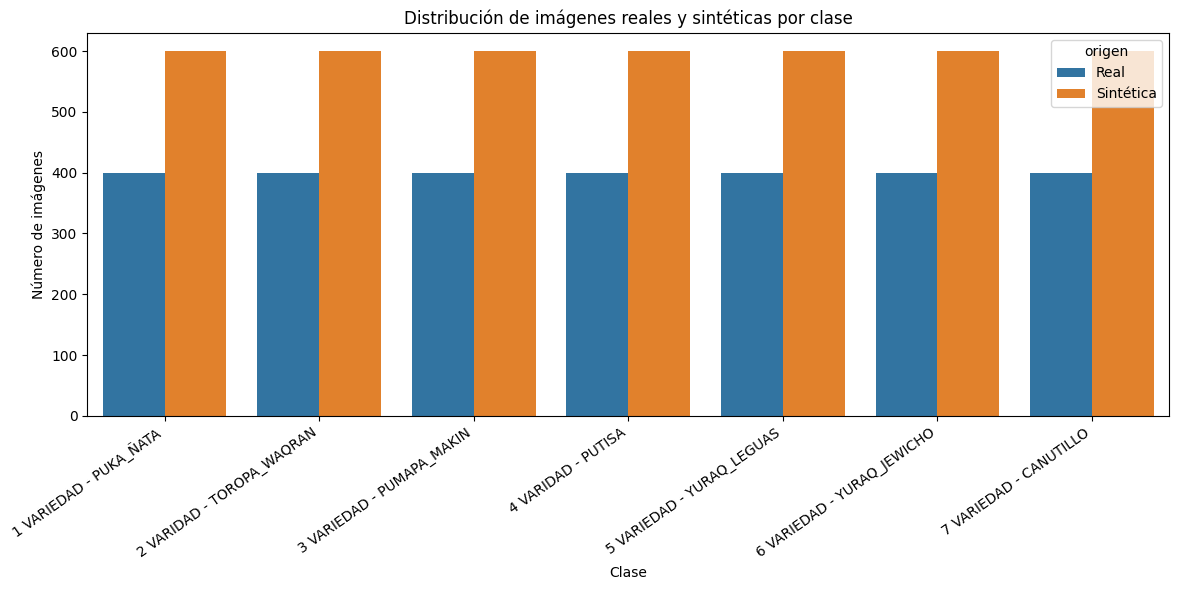

Resumen de tamaños de imagen muestreados


,width,height,aspect_ratio
count,600.000000,600.000000,600.000000
mean,2852.080000,2055.413333,1.199167
std,2563.487773,1583.561254,0.244982
min,768.000000,768.000000,1.000000
25%,768.000000,768.000000,1.000000
50%,768.000000,768.000000,1.000000
75%,6000.000000,4000.000000,1.500000
max,6000.000000,4000.000000,1.500000


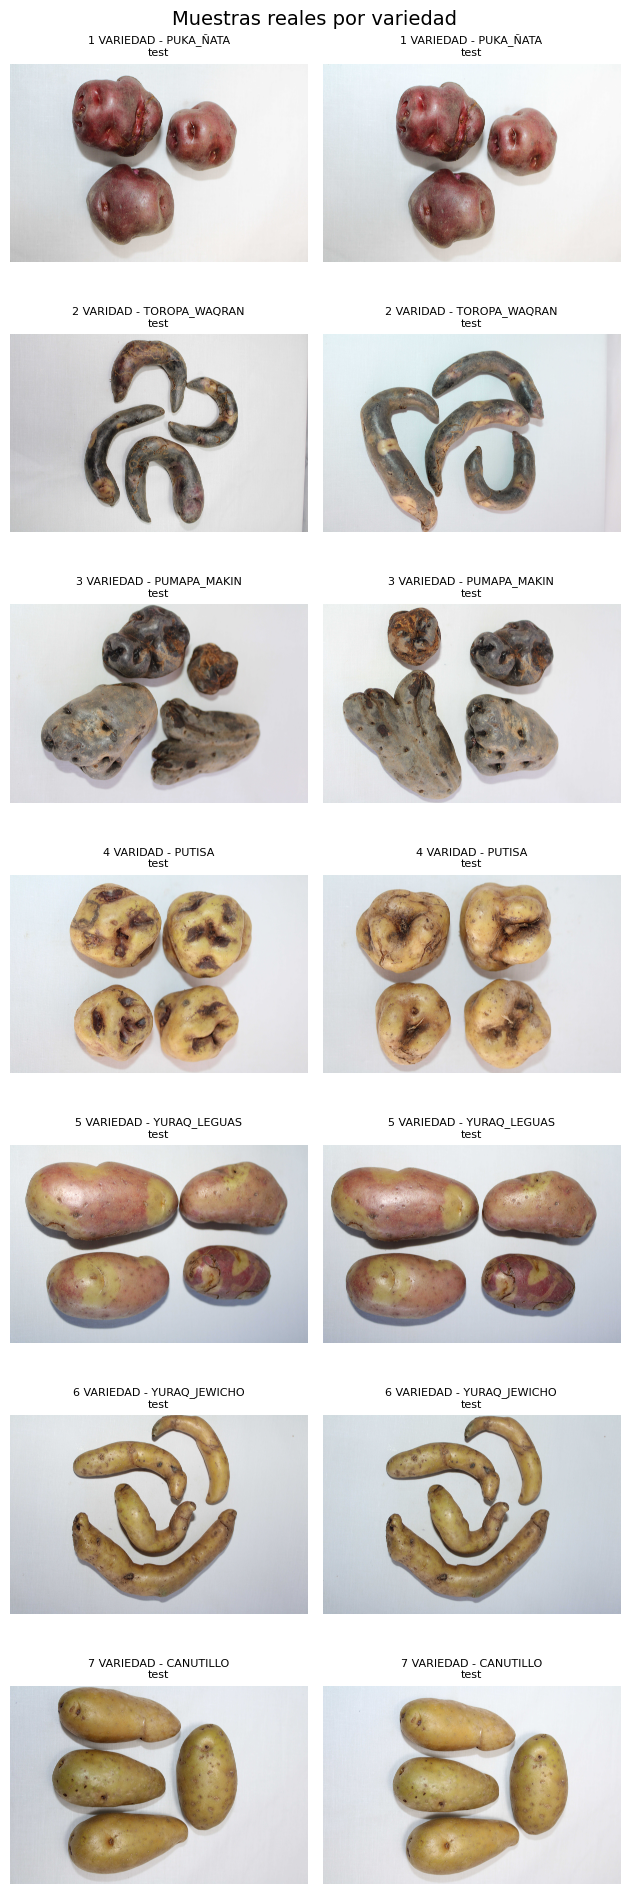

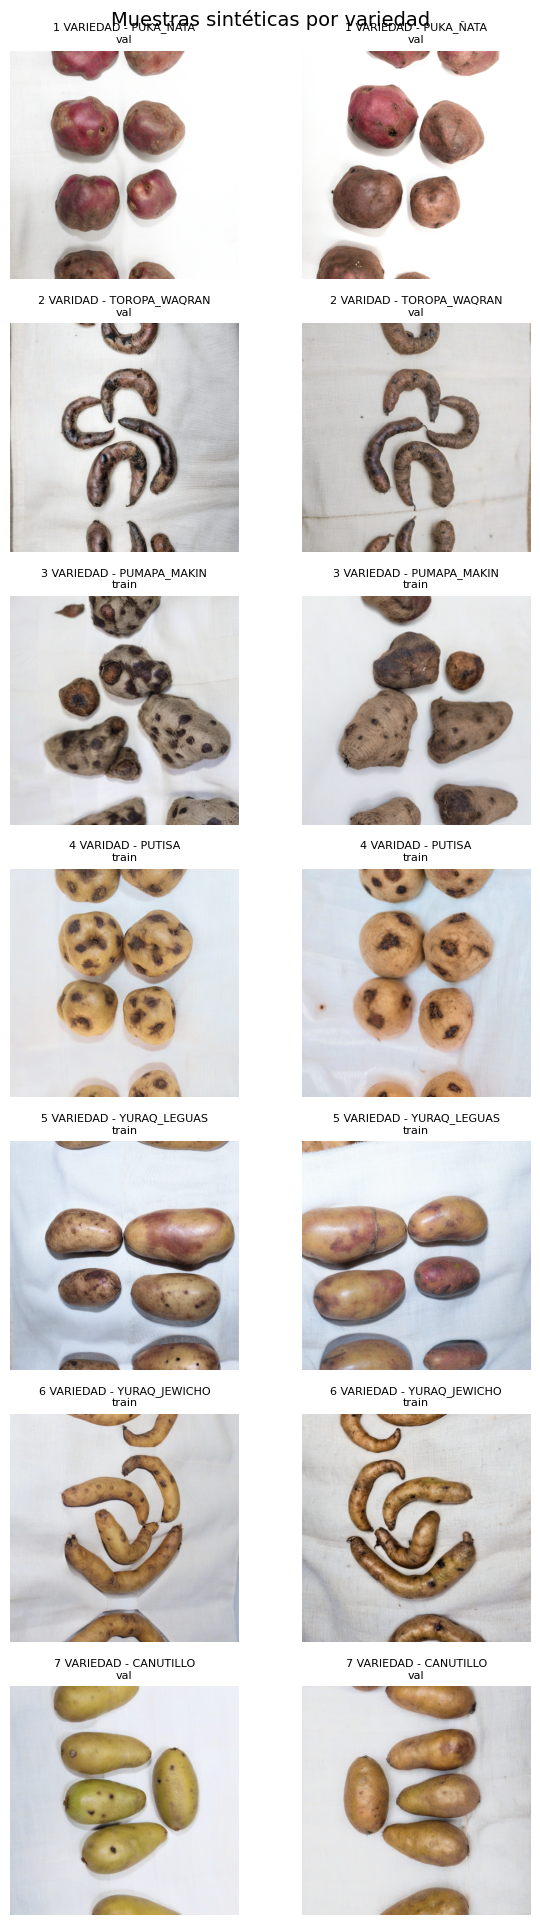

Artefactos de previsualización guardados en: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/previsualizacion_dataset


In [4]:
# Vista previa científica del dataset y control visual de calidad
SYNTHETIC_MARKER = "__sd_img2img_synthetic_1000"
DATA_PREVIEW_DIR = OUTPUT_DIR / "previsualizacion_dataset"
DATA_PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

preview_df = manifest_df.copy()
if "is_synthetic" in preview_df.columns:
    preview_df["is_synthetic"] = preview_df["is_synthetic"].map(parse_bool_value)
else:
    preview_df["is_synthetic"] = preview_df["path"].astype(str).str.contains(SYNTHETIC_MARKER, regex=False)
preview_df["origin"] = np.where(preview_df["is_synthetic"], "synthetic", "real")
preview_df["file_name"] = preview_df["path"].map(lambda p: Path(p).name)
preview_df["exists"] = preview_df["path"].map(lambda p: Path(p).exists())

if not preview_df["exists"].all():
    missing_preview_path = DATA_PREVIEW_DIR / "paths_faltantes_previsualizacion.csv"
    preview_df[~preview_df["exists"]].to_csv(missing_preview_path, index=False, encoding="utf-8")
    raise FileNotFoundError(f"Hay rutas inexistentes en el dataset. Revisa {missing_preview_path}")

class_split_table = preview_df.pivot_table(index="class_name", columns="split", values="path", aggfunc="count", fill_value=0)
class_synthetic_table = preview_df.pivot_table(index="class_name", columns="is_synthetic", values="path", aggfunc="count", fill_value=0)
class_synthetic_table = class_synthetic_table.rename(columns={False: "real", True: "synthetic"})
dataset_overview_df = class_split_table.join(class_synthetic_table, how="left").fillna(0).astype(int)
dataset_overview_df["total"] = dataset_overview_df.sum(axis=1)
dataset_overview_df.to_csv(DATA_PREVIEW_DIR / "resumen_dataset_por_clase.csv", encoding="utf-8")

overall_summary_df = pd.DataFrame([{
    "num_classes": NUM_CLASSES,
    "total_images_manifest": len(preview_df),
    "train_images": len(train_df),
    "val_images": len(val_df),
    "test_images": len(test_df),
    "real_images": int((~preview_df["is_synthetic"]).sum()),
    "synthetic_images": int(preview_df["is_synthetic"].sum()),
    "all_paths_exist": bool(preview_df["exists"].all()),
}])
overall_summary_df.to_csv(DATA_PREVIEW_DIR / "resumen_general_dataset.csv", index=False, encoding="utf-8")

print("Resumen general del dataset")
display(overall_summary_df)
print("Distribución por clase, split y origen")
display(dataset_overview_df)

# Gráficos de distribución
plot_df = preview_df.groupby(["class_name", "split"]).size().reset_index(name="count")
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="class_name", y="count", hue="split")
plt.title("Distribución de imágenes por clase y split")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(DATA_PREVIEW_DIR / "distribucion_clase_split.png", dpi=150, bbox_inches="tight")
plt.show()

origin_df = preview_df.groupby(["class_name", "is_synthetic"]).size().reset_index(name="count")
origin_df["origen"] = np.where(origin_df["is_synthetic"], "Sintética", "Real")
plt.figure(figsize=(12, 6))
sns.barplot(data=origin_df, x="class_name", y="count", hue="origen")
plt.title("Distribución de imágenes reales y sintéticas por clase")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(DATA_PREVIEW_DIR / "distribucion_real_sintetica.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadística de tamaños de imagen en una muestra acotada para no demorar Kaggle.
size_sample = preview_df.sample(n=min(len(preview_df), 600), random_state=SEED).copy()
size_rows = []
for _, row in size_sample.iterrows():
    with Image.open(row["path"]) as img:
        width, height = img.size
    size_rows.append({
        "path": row["path"],
        "class_name": row["class_name"],
        "split": row["split"],
        "is_synthetic": bool(row["is_synthetic"]),
        "width": width,
        "height": height,
        "aspect_ratio": width / max(height, 1),
    })
image_size_df = pd.DataFrame(size_rows)
image_size_df.to_csv(DATA_PREVIEW_DIR / "muestra_tamanos_imagenes.csv", index=False, encoding="utf-8")
print("Resumen de tamaños de imagen muestreados")
display(image_size_df[["width", "height", "aspect_ratio"]].describe())

# Muestras visuales reales y sintéticas por clase.
def plot_dataset_samples(sample_df, title, out_name, samples_per_class=2):
    selected = []
    for class_name in class_names:
        part = sample_df[sample_df["class_name"] == class_name].head(samples_per_class)
        selected.extend(part.to_dict("records"))
    if not selected:
        print(f"No hay imágenes para: {title}")
        return
    cols = samples_per_class
    rows = len(class_names)
    plt.figure(figsize=(cols * 3.2, rows * 2.8))
    for i, row in enumerate(selected, 1):
        img = Image.open(row["path"]).convert("RGB")
        ax = plt.subplot(rows, cols, i)
        ax.imshow(img)
        ax.set_title(f"{row['class_name']}\n{row['split']}", fontsize=8)
        ax.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(DATA_PREVIEW_DIR / out_name, dpi=150, bbox_inches="tight")
    plt.show()

real_samples_df = preview_df[~preview_df["is_synthetic"]].sort_values(["class_name", "split", "path"])
synthetic_samples_df = preview_df[preview_df["is_synthetic"]].sort_values(["class_name", "path"])
plot_dataset_samples(real_samples_df, "Muestras reales por variedad", "muestras_reales_por_variedad.png", samples_per_class=2)
plot_dataset_samples(synthetic_samples_df, "Muestras sintéticas por variedad", "muestras_sinteticas_por_variedad.png", samples_per_class=2)

print(f"Artefactos de previsualización guardados en: {DATA_PREVIEW_DIR}")

In [5]:
# Auditoría de fugas entre particiones y control del protocolo de split

def cross_split_report(df, column):
    clean_df = df[df[column].notna() & df[column].astype(str).str.strip().ne("")].copy()
    spread = clean_df.groupby(column)["split"].nunique()
    risky_values = spread[spread > 1].index
    return clean_df[clean_df[column].isin(risky_values)].sort_values([column, "split", "path"])

if SPLIT_PROTOCOL == "thesis_real_eval":
    synth_eval = manifest_df[manifest_df["is_synthetic"] & manifest_df["split"].isin(["val", "test"])]
    if not synth_eval.empty:
        path = OUTPUT_DIR / f"sinteticas_en_val_test_{TAG}.csv"
        synth_eval.to_csv(path, index=False, encoding="utf-8")
        raise RuntimeError(f"El protocolo de tesis exige val/test reales. Revisa {path}")

exact_leaks = cross_split_report(manifest_df, "sha256")
group_leaks = cross_split_report(manifest_df, "group_id")

if not exact_leaks.empty:
    path = OUTPUT_DIR / f"fuga_hash_exacta_{TAG}.csv"
    exact_leaks.to_csv(path, index=False, encoding="utf-8")
    raise RuntimeError(f"Fuga exacta detectada. Revisa {path}")

if not group_leaks.empty:
    path = OUTPUT_DIR / f"fuga_group_id_{TAG}.csv"
    group_leaks.to_csv(path, index=False, encoding="utf-8")
    raise RuntimeError(f"Fuga por group_id/source_group_id detectada. Revisa {path}")

if RUN_STRICT_NEAR_DUP_AUDIT:
    near_rows = []
    for class_name, class_df in manifest_df.groupby("class_name", sort=True):
        hashes = class_df[["visual_hash", "split", "path"]].drop_duplicates("visual_hash").to_dict("records")
        for i in range(len(hashes)):
            for j in range(i + 1, len(hashes)):
                if hashes[i]["split"] == hashes[j]["split"]:
                    continue
                distance = hamming_hex(hashes[i]["visual_hash"], hashes[j]["visual_hash"])
                if distance <= 8:
                    near_rows.append({"class_name": class_name, "hamming_distance": distance, "path_a": hashes[i]["path"], "split_a": hashes[i]["split"], "path_b": hashes[j]["path"], "split_b": hashes[j]["split"]})

    near_df = pd.DataFrame(near_rows)
    if not near_df.empty:
        path = OUTPUT_DIR / f"fuga_near_duplicates_{TAG}.csv"
        near_df.to_csv(path, index=False, encoding="utf-8")
        raise RuntimeError(f"Near-duplicates cruzan particiones. Revisa {path}")

print(f"Auditoría OK para SPLIT_PROTOCOL={SPLIT_PROTOCOL}: sin duplicados exactos ni group_id cruzando train/val/test.")


Auditoría OK para SPLIT_PROTOCOL=mixed_synthetic_eval: sin duplicados exactos ni group_id cruzando train/val/test.


In [6]:
# Pipeline tf.data: train con augmentación; val/test según SPLIT_PROTOCOL sin augmentación
IMG_SIZE = 224
PER_REPLICA_BATCH = 32 if FAST_KAGGLE_RUN else 24
BATCH_SIZE = PER_REPLICA_BATCH * strategy.num_replicas_in_sync
CACHE_DATA = True
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method="bilinear")
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.int32)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.10, fill_mode="reflect", seed=SEED),
    tf.keras.layers.RandomZoom((-0.08, 0.10), (-0.08, 0.10), fill_mode="reflect", seed=SEED),
    tf.keras.layers.RandomTranslation(0.06, 0.06, fill_mode="reflect", seed=SEED),
    tf.keras.layers.RandomContrast(0.12, seed=SEED),
], name="train_augmentation")

def photometric_aug(images):
    x = tf.clip_by_value(images / 255.0, 0.0, 1.0)
    x = tf.image.random_brightness(x, max_delta=0.05, seed=SEED)
    x = tf.image.random_contrast(x, lower=0.90, upper=1.10, seed=SEED)
    x = tf.image.random_saturation(x, lower=0.92, upper=1.08, seed=SEED)
    return tf.clip_by_value(x, 0.0, 1.0) * 255.0

def augment_batch(images, labels):
    images = augmentation(images, training=True)
    images = photometric_aug(images)
    return images, labels

def build_tf_dataset(split_df, training=False):
    ds = tf.data.Dataset.from_tensor_slices((split_df["path"].astype(str).tolist(), split_df["label"].astype("int32").tolist()))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if CACHE_DATA:
        ds = ds.cache()
    if training:
        ds = ds.shuffle(buffer_size=len(split_df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(augment_batch, num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (x, tf.one_hot(y, depth=NUM_CLASSES)), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = build_tf_dataset(train_df, training=True)
val_ds = build_tf_dataset(val_df, training=False)
test_ds = build_tf_dataset(test_df, training=False)
print("Batch size global:", BATCH_SIZE)
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

Batch size global: 64
Train/Val/Test: 4874 1079 1047


In [7]:
# Modelo EfficientNetB0 + visualización y complejidad
from tensorflow.keras import layers, regularizers, optimizers
from tensorflow.keras.applications import EfficientNetB0

def count_trainable_params(model):
    trainable = int(sum(np.prod(v.shape) for v in model.trainable_weights))
    total = int(model.count_params())
    return total, trainable, total - trainable

def visualize_model(model, output_dir, name="cnn"):
    output_dir = Path(output_dir)
    summary_path = output_dir / f"resumen_modelo_{name}.txt"
    with open(summary_path, "w", encoding="utf-8") as f:
        model.summary(print_fn=lambda line: f.write(line + "\n"))
    try:
        tf.keras.utils.plot_model(model, to_file=str(output_dir / f"arquitectura_{name}.png"), show_shapes=True, show_trainable=True, dpi=120)
        print("Arquitectura guardada en:", output_dir / f"arquitectura_{name}.png")
    except Exception as exc:
        print("No se pudo generar plot_model:", exc)
    total, trainable, non_trainable = count_trainable_params(model)
    complexity = pd.DataFrame([{
        "modelo": model.name,
        "img_size": IMG_SIZE,
        "num_clases": NUM_CLASSES,
        "total_params": total,
        "trainable_params": trainable,
        "non_trainable_params": non_trainable,
        "batch_size_global": BATCH_SIZE,
        "replicas": strategy.num_replicas_in_sync,
        "mixed_precision_policy": str(mixed_precision.global_policy()),
    }])
    complexity.to_csv(output_dir / f"complejidad_{name}.csv", index=False)
    display(complexity)
    return complexity

with strategy.scope():
    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="input")
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="avg_pool")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(0.005), name="head_dense")(x)
    x = layers.Dropout(0.45, name="head_dropout")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32", name="predictions")(x)
    model = tf.keras.Model(inputs, outputs, name="efficientnetb0_papas_kaggle")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08), metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")])

model.summary()
complexity_cnn = visualize_model(model, OUTPUT_DIR, "cnn")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "efficientnetb0_papas_kaggle"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_bn (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dense (Dense)              │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Arquitectura guardada en: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/arquitectura_cnn.png


,modelo,img_size,num_clases,total_params,trainable_params,non_trainable_params,batch_size_global,replicas,mixed_precision_policy
0,efficientnetb0_papas_kaggle,224,7,4384426,332295,4052131,64,2,"<DTypePolicy ""mixed_float16"">"


In [8]:
# Entrenamiento en dos fases: cabeza y fine-tuning
EPOCHS = 12 if FAST_KAGGLE_RUN else 30
HEAD_EPOCHS = 4 if FAST_KAGGLE_RUN else 10
FINE_TUNE_EPOCHS = max(EPOCHS - HEAD_EPOCHS, 1)
PATIENCE = 3 if FAST_KAGGLE_RUN else 8
FINE_TUNE_LR = 1e-5
FINE_TUNE_LAST_LAYERS = 45

best_model_path = MODEL_DIR / "best_model_cnn.keras"
head_model_path = MODEL_DIR / "best_model_cnn_head.keras"
fine_model_path = MODEL_DIR / "best_model_cnn_finetune.keras"
final_model_path = MODEL_DIR / "clasificador_papas_cnn_final.keras"

def callbacks(path):
    return [
        tf.keras.callbacks.ModelCheckpoint(str(path), monitor="val_loss", mode="min", save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=PATIENCE, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.3, patience=2, min_lr=1e-7, verbose=1),
        tf.keras.callbacks.CSVLogger(str(OUTPUT_DIR / "log_entrenamiento_cnn.csv"), append=True),
    ]

def history_frame(history_obj, phase, offset):
    frame = pd.DataFrame(history_obj.history)
    frame.insert(0, "epoch", np.arange(offset + 1, offset + len(frame) + 1))
    frame.insert(1, "phase", phase)
    return frame

print("Fase 1/2: cabeza clasificadora")
base_model.trainable = False
with strategy.scope():
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08), metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")])
history_head = model.fit(train_ds, validation_data=val_ds, epochs=HEAD_EPOCHS, callbacks=callbacks(head_model_path), verbose=1)

print("Fase 2/2: fine-tuning")
base_model.trainable = True
for layer in base_model.layers[:-FINE_TUNE_LAST_LAYERS]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
with strategy.scope():
    model.compile(optimizer=optimizers.Adam(learning_rate=FINE_TUNE_LR), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08), metrics=[tf.keras.metrics.CategoricalAccuracy(name="accuracy")])
history_fine = model.fit(train_ds, validation_data=val_ds, epochs=FINE_TUNE_EPOCHS, callbacks=callbacks(fine_model_path), verbose=1)

history_df = pd.concat([history_frame(history_head, "head", 0), history_frame(history_fine, "fine_tune", len(history_head.history["loss"]))], ignore_index=True)
history_df.to_csv(OUTPUT_DIR / "historial_entrenamiento_cnn.csv", index=False, encoding="utf-8")

head_best = float(min(history_head.history["val_loss"]))
fine_best = float(min(history_fine.history["val_loss"]))
selected_path = fine_model_path if fine_best <= head_best and fine_model_path.exists() else head_model_path
best_phase = "fine_tune" if selected_path == fine_model_path else "head"
model = tf.keras.models.load_model(str(selected_path))
model.save(str(final_model_path))
print("Mejor fase CNN:", best_phase)
print("Modelo final:", final_model_path)
visualize_model(model, OUTPUT_DIR, "cnn_final")

Fase 1/2: cabeza clasificadora
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device

I0000 00:00:1777590583.373962      76 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777590584.551512      77 cuda_dnn.cc:529] Loaded cuDNN version 91002


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.7974 - loss: 3.0017
Epoch 1: val_loss improved from inf to 2.16002, saving model to /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/models/best_model_cnn_head.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.7986 - loss: 2.9967 - val_accuracy: 0.9824 - val_loss: 2.1600 - learning_rate: 0.0010
Epoch 2/4
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9673 - loss: 1.9156
Epoch 2: val_loss improved from 2.16002 to 1.48297, saving model to /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/models/best_model_cnn_head.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 50s 617ms/step - accuracy: 0.9672 - loss: 1.9117 - val_accuracy: 0.9861 - val_loss: 1.4830 - learning_rate: 0.0010
Epoch 3/4
76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9794 - loss: 1.3397
Epoch 3: val_loss improved from 1.48297 to 1.04598, saving model to /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/models/best_model_cnn_he

Arquitectura guardada en: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/arquitectura_cnn_final.png


,modelo,img_size,num_clases,total_params,trainable_params,non_trainable_params,batch_size_global,replicas,mixed_precision_policy
0,efficientnetb0_papas_kaggle,224,7,4384426,2398615,1985811,64,2,"<DTypePolicy ""mixed_float16"">"


,modelo,img_size,num_clases,total_params,trainable_params,non_trainable_params,batch_size_global,replicas,mixed_precision_policy
0,efficientnetb0_papas_kaggle,224,7,4384426,2398615,1985811,64,2,"<DTypePolicy ""mixed_float16"">"


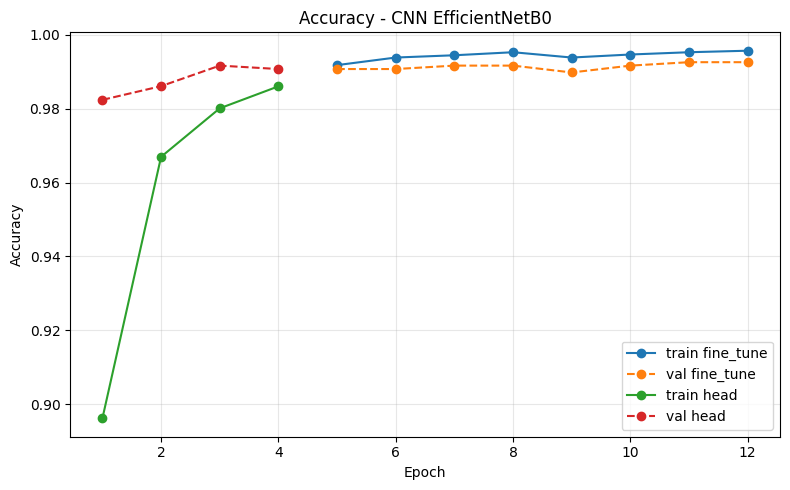

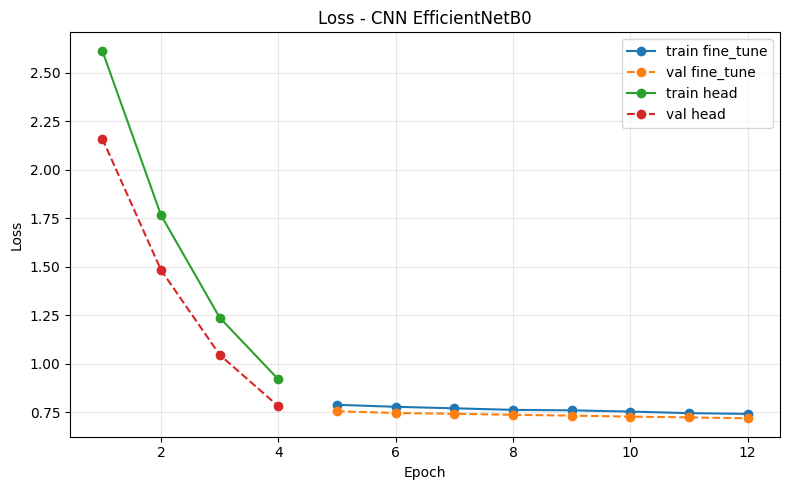

In [9]:
# Curvas de entrenamiento
plt.figure(figsize=(8, 5))
for phase, part in history_df.groupby("phase"):
    plt.plot(part["epoch"], part["accuracy"], marker="o", label=f"train {phase}")
    plt.plot(part["epoch"], part["val_accuracy"], marker="o", linestyle="--", label=f"val {phase}")
plt.title("Accuracy - CNN EfficientNetB0")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curva_accuracy_cnn.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for phase, part in history_df.groupby("phase"):
    plt.plot(part["epoch"], part["loss"], marker="o", label=f"train {phase}")
    plt.plot(part["epoch"], part["val_loss"], marker="o", linestyle="--", label=f"val {phase}")
plt.title("Loss - CNN EfficientNetB0")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curva_loss_cnn.png", dpi=150, bbox_inches="tight")
plt.show()

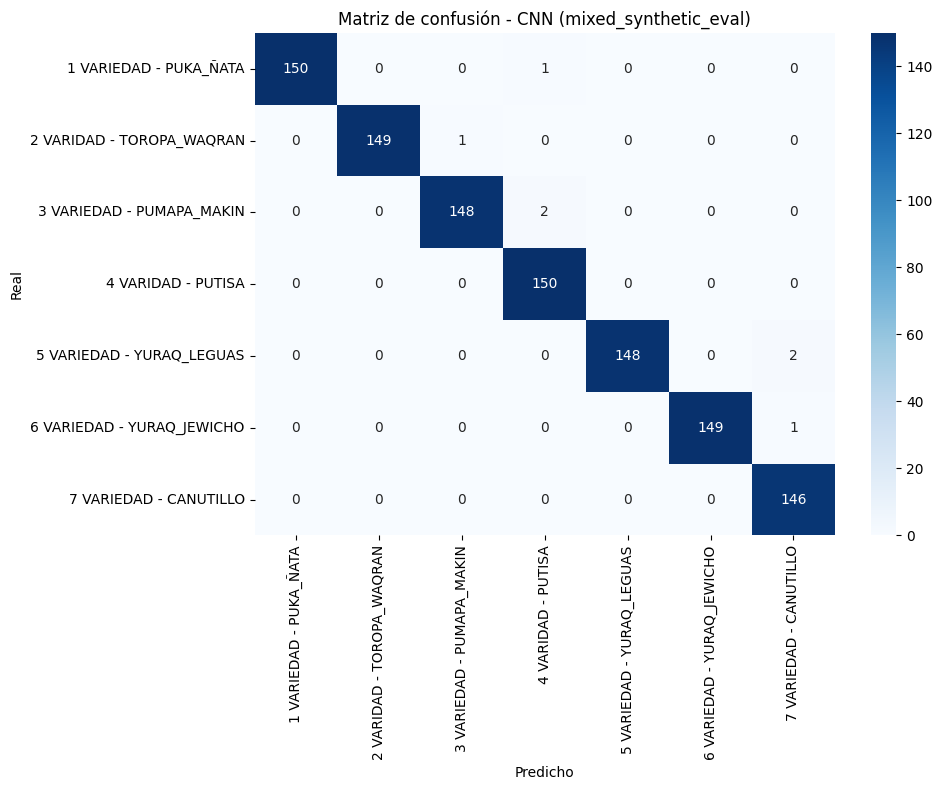

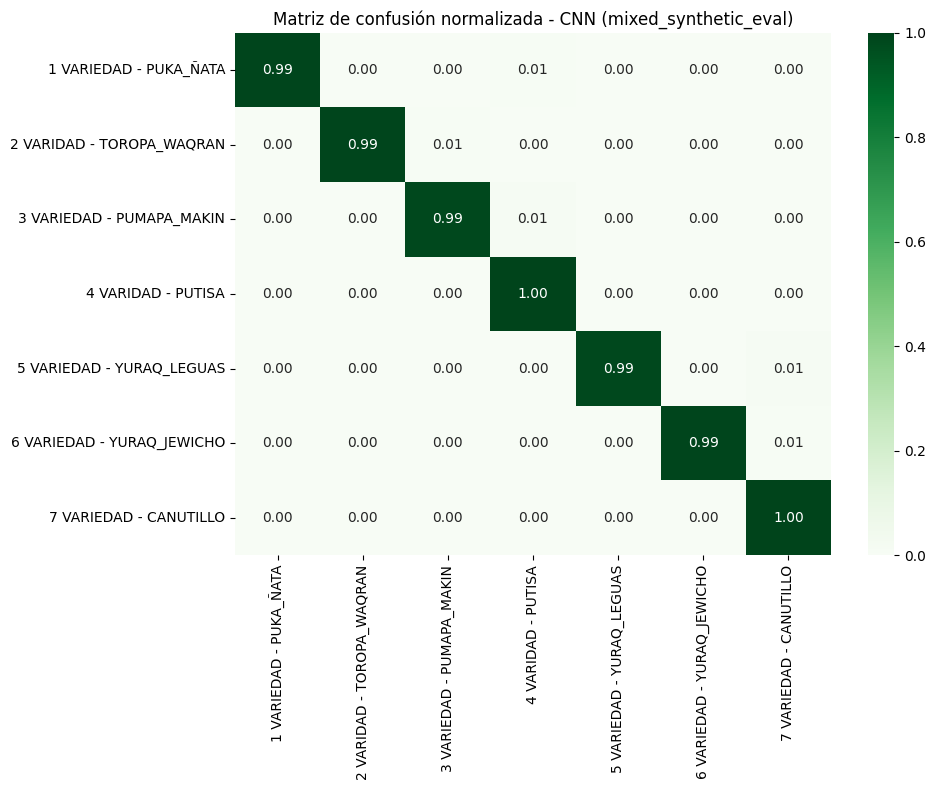

,modelo,split_protocol,split_final,num_clases,n_train,n_val,n_test,n_test_real,n_test_synthetic,best_epoch_by_val_loss,...,test_loss,test_accuracy_keras,test_accuracy_sklearn,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,CNN_EfficientNetB0_dataset_combinado_experimen...,mixed_synthetic_eval,test,7,4874,1079,1047,412,635,12,...,0.713295,0.993314,0.993314,0.99334,0.993364,0.99334,0.99331,0.993422,0.993314,0.993327


,modelo,split_protocol,split_final,eval_subset,num_clases,n_train,n_val,n_test,n_samples,n_real,...,test_loss,test_accuracy_framework,test_accuracy_sklearn,test_balanced_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,CNN_EfficientNetB0_dataset_combinado_experimen...,mixed_synthetic_eval,test,global,7,4874,1079,1047,1047,412,...,0.713295,0.993314,0.993314,0.993340,0.993364,0.993340,0.99331,0.993422,0.993314,0.993327
1,CNN_EfficientNetB0_dataset_combinado_experimen...,mixed_synthetic_eval,test,real_only,7,4874,1079,1047,412,412,...,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
2,CNN_EfficientNetB0_dataset_combinado_experimen...,mixed_synthetic_eval,test,synthetic_only,7,4874,1079,1047,635,0,...,NaN,NaN,0.988976,0.988728,0.989428,0.988728,0.98897,0.989254,0.988976,0.989006


,precision,recall,f1-score,support
1 VARIEDAD - PUKA_ÑATA,1.000000,0.993377,0.996678,151.000000
2 VARIDAD - TOROPA_WAQRAN,1.000000,0.993333,0.996656,150.000000
3 VARIEDAD - PUMAPA_MAKIN,0.993289,0.986667,0.989967,150.000000
4 VARIDAD - PUTISA,0.980392,1.000000,0.990099,150.000000
5 VARIEDAD - YURAQ_LEGUAS,1.000000,0.986667,0.993289,150.000000
6 VARIEDAD - YURAQ_JEWICHO,1.000000,0.993333,0.996656,150.000000
7 VARIEDAD - CANUTILLO,0.979866,1.000000,0.989831,146.000000
accuracy,0.993314,0.993314,0.993314,0.993314
macro avg,0.993364,0.993340,0.993310,1047.000000
weighted avg,0.993422,0.993314,0.993327,1047.000000


In [10]:
# Evaluación final en test según SPLIT_PROTOCOL

def predict_tf_dataset(model, dataset):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_prob.extend(probs.tolist())
        y_pred.extend(np.argmax(probs, axis=1).tolist())
        y_true.extend(np.argmax(labels.numpy(), axis=1).tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


def subset_metric_row(model_name, subset_name, mask, y_true, y_pred, framework_loss=np.nan, framework_acc=np.nan):
    mask = np.asarray(mask, dtype=bool)
    n_samples = int(mask.sum())
    row = {
        "modelo": model_name,
        "split_protocol": SPLIT_PROTOCOL,
        "split_final": "test",
        "eval_subset": subset_name,
        "num_clases": NUM_CLASSES,
        "n_train": len(train_df),
        "n_val": len(val_df),
        "n_test": len(test_df),
        "n_samples": n_samples,
        "n_real": int((test_origin[mask] == "real").sum()) if n_samples else 0,
        "n_synthetic": int((test_origin[mask] == "synthetic").sum()) if n_samples else 0,
        "test_loss": float(framework_loss) if not pd.isna(framework_loss) else np.nan,
        "test_accuracy_framework": float(framework_acc) if not pd.isna(framework_acc) else np.nan,
    }
    if n_samples == 0:
        row.update({
            "test_accuracy_sklearn": np.nan,
            "test_balanced_accuracy": np.nan,
            "test_precision_macro": np.nan,
            "test_recall_macro": np.nan,
            "test_f1_macro": np.nan,
            "test_precision_weighted": np.nan,
            "test_recall_weighted": np.nan,
            "test_f1_weighted": np.nan,
        })
        return row
    yt = y_true[mask]
    yp = y_pred[mask]
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(yt, yp, average="weighted", zero_division=0)
    row.update({
        "test_accuracy_sklearn": float(accuracy_score(yt, yp)),
        "test_balanced_accuracy": float(balanced_accuracy_score(yt, yp)),
        "test_precision_macro": float(precision_macro),
        "test_recall_macro": float(recall_macro),
        "test_f1_macro": float(f1_macro),
        "test_precision_weighted": float(precision_weighted),
        "test_recall_weighted": float(recall_weighted),
        "test_f1_weighted": float(f1_weighted),
    })
    return row


def save_subset_report(prefix, subset_name, mask, y_true, y_pred):
    mask = np.asarray(mask, dtype=bool)
    if not mask.any():
        return None
    report = pd.DataFrame(classification_report(
        y_true[mask], y_pred[mask], labels=list(range(NUM_CLASSES)), target_names=class_names,
        output_dict=True, zero_division=0
    )).T
    out_path = OUTPUT_DIR / f"classification_report_{prefix}_{subset_name}.csv"
    report.to_csv(out_path, encoding="utf-8")
    return report


test_loss, test_acc_keras = model.evaluate(test_ds, verbose=0)
y_true, y_pred, y_prob = predict_tf_dataset(model, test_ds)
assert len(y_true) == len(test_df)

test_origin = np.where(test_df["is_synthetic"].map(parse_bool_value).to_numpy(), "synthetic", "real")
test_predictions_df = test_df[["path", "class_name", "label", "split", "is_synthetic", "source_path", "source_group_id", "group_id"]].copy()
test_predictions_df["split_protocol"] = SPLIT_PROTOCOL
test_predictions_df["origin"] = test_origin
test_predictions_df["true_label"] = y_true
test_predictions_df["true_class"] = [class_names[i] for i in y_true]
test_predictions_df["pred_label"] = y_pred
test_predictions_df["pred_class"] = [class_names[i] for i in y_pred]
test_predictions_df["confidence_top1"] = y_prob.max(axis=1)
test_predictions_df["is_correct"] = y_true == y_pred
for rank in range(min(3, NUM_CLASSES)):
    top_idx = np.argsort(y_prob, axis=1)[:, ::-1][:, rank]
    test_predictions_df[f"top{rank + 1}_class"] = [class_names[i] for i in top_idx]
    test_predictions_df[f"top{rank + 1}_prob"] = y_prob[np.arange(len(y_prob)), top_idx]
test_predictions_df.to_csv(OUTPUT_DIR / "predicciones_test_cnn.csv", index=False, encoding="utf-8")

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(OUTPUT_DIR / "matriz_confusion_cnn.csv", encoding="utf-8")

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - CNN ({SPLIT_PROTOCOL})")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matriz_confusion_cnn.png", dpi=150, bbox_inches="tight")
plt.show()

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm_norm, index=class_names, columns=class_names), annot=True, fmt=".2f", cmap="Greens")
plt.title(f"Matriz de confusión normalizada - CNN ({SPLIT_PROTOCOL})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matriz_confusion_normalizada_cnn.png", dpi=150, bbox_inches="tight")
plt.show()

report_df = save_subset_report("cnn", "global", np.ones(len(y_true), dtype=bool), y_true, y_pred)
real_report_df = save_subset_report("cnn", "real_only", test_origin == "real", y_true, y_pred)
synthetic_report_df = save_subset_report("cnn", "synthetic_only", test_origin == "synthetic", y_true, y_pred)
if report_df is not None:
    report_df.to_csv(OUTPUT_DIR / "classification_report_cnn.csv", encoding="utf-8")

metrics_by_subset_df = pd.DataFrame([
    subset_metric_row("CNN_EfficientNetB0_dataset_combinado_experimental_kaggle", "global", np.ones(len(y_true), dtype=bool), y_true, y_pred, test_loss, test_acc_keras),
    subset_metric_row("CNN_EfficientNetB0_dataset_combinado_experimental_kaggle", "real_only", test_origin == "real", y_true, y_pred),
    subset_metric_row("CNN_EfficientNetB0_dataset_combinado_experimental_kaggle", "synthetic_only", test_origin == "synthetic", y_true, y_pred),
])
metrics_by_subset_df.to_csv(OUTPUT_DIR / "metricas_test_por_origen_cnn.csv", index=False, encoding="utf-8")
metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "global"].to_csv(OUTPUT_DIR / "metricas_test_global.csv", index=False, encoding="utf-8")
metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "real_only"].to_csv(OUTPUT_DIR / "metricas_test_real_only.csv", index=False, encoding="utf-8")
metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "synthetic_only"].to_csv(OUTPUT_DIR / "metricas_test_synthetic_only.csv", index=False, encoding="utf-8")

best_idx = int(history_df["val_loss"].idxmin())
global_row = metrics_by_subset_df[metrics_by_subset_df["eval_subset"] == "global"].iloc[0].to_dict()
metrics_df = pd.DataFrame([{
    "modelo": "CNN_EfficientNetB0_dataset_combinado_experimental_kaggle",
    "split_protocol": SPLIT_PROTOCOL,
    "split_final": "test",
    "num_clases": NUM_CLASSES,
    "n_train": len(train_df),
    "n_val": len(val_df),
    "n_test": len(test_df),
    "n_test_real": int((test_origin == "real").sum()),
    "n_test_synthetic": int((test_origin == "synthetic").sum()),
    "best_epoch_by_val_loss": int(history_df.loc[best_idx, "epoch"]),
    "best_phase": best_phase,
    "best_val_loss": float(history_df.loc[best_idx, "val_loss"]),
    "best_val_accuracy": float(history_df.loc[best_idx, "val_accuracy"]),
    "test_loss": float(test_loss),
    "test_accuracy_keras": float(test_acc_keras),
    "test_accuracy_sklearn": global_row["test_accuracy_sklearn"],
    "test_balanced_accuracy": global_row["test_balanced_accuracy"],
    "test_precision_macro": global_row["test_precision_macro"],
    "test_recall_macro": global_row["test_recall_macro"],
    "test_f1_macro": global_row["test_f1_macro"],
    "test_precision_weighted": global_row["test_precision_weighted"],
    "test_recall_weighted": global_row["test_recall_weighted"],
    "test_f1_weighted": global_row["test_f1_weighted"],
}])
metrics_df.to_csv(OUTPUT_DIR / "metricas_cnn.csv", index=False, encoding="utf-8")
display(metrics_df)
display(metrics_by_subset_df)
if report_df is not None:
    display(report_df)

In [11]:
# Inferencia controlada con el mismo orden de clases
from tensorflow.keras.preprocessing import image

classes_from_file = (OUTPUT_DIR / "classes.txt").read_text(encoding="utf-8").splitlines()
assert classes_from_file == class_names

def predict_image_cnn(img_path, top_k=3):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = image.img_to_array(img).astype("float32")
    probs = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:top_k]
    return [(class_names[i], float(probs[i])) for i in top_idx]

print("Función lista: predict_image_cnn('/ruta/imagen.jpg')")

Función lista: predict_image_cnn('/ruta/imagen.jpg')


## Exportación ONNX del modelo entrenado

Esta sección exporta el modelo final entrenado a formato ONNX para despliegue, interoperabilidad y validación externa. La celda carga el mejor modelo guardado desde disco, genera el archivo `.onnx`, valida su estructura con `onnx.checker` y compara una inferencia entre el framework original y ONNX Runtime.

In [12]:
# Exportación ONNX profesional - CNN EfficientNetB0
RUN_ONNX_EXPORT = True
ONNX_OPSET = 13
ONNX_EXPORT_DIR = MODEL_DIR / "onnx"
ONNX_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
CNN_ONNX_PATH = ONNX_EXPORT_DIR / "clasificador_papas_cnn_final.onnx"
CNN_ONNX_REPORT_PATH = ONNX_EXPORT_DIR / "reporte_exportacion_onnx_cnn.csv"

if RUN_ONNX_EXPORT:
    import sys
    import subprocess
    import importlib.util

    def ensure_python_packages(packages):
        missing = [pkg for pkg, import_name in packages if importlib.util.find_spec(import_name) is None]
        if missing:
            print("Instalando dependencias ONNX faltantes:", missing)
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

    ensure_python_packages([
        ("tf2onnx", "tf2onnx"),
        ("onnx", "onnx"),
        ("onnxruntime", "onnxruntime"),
    ])

    import tf2onnx
    import onnx
    import onnxruntime as ort

    if not hasattr(np, "cast"):
        class _NumpyCastCompat:
            def __getitem__(self, dtype):
                return lambda array: np.asarray(array, dtype=dtype)
        np.cast = _NumpyCastCompat()

    def find_cnn_model_for_onnx():
        candidates = []
        for var_name in ["TRAINED_CNN_MODEL_PATH", "final_model_path", "best_model_path", "fine_model_path", "head_model_path"]:
            if var_name in globals() and globals()[var_name] is not None:
                candidates.append(Path(globals()[var_name]))
        candidates.extend([
            MODEL_DIR / "clasificador_papas_cnn_final.keras",
            MODEL_DIR / "best_model_cnn_finetune.keras",
            MODEL_DIR / "best_model_cnn.keras",
            MODEL_DIR / "best_model_cnn_head.keras",
        ])
        for candidate in candidates:
            if candidate.exists():
                return candidate
        search_roots = [MODEL_DIR, OUTPUT_DIR]
        if Path("/kaggle/input").exists():
            search_roots.append(Path("/kaggle/input"))
        if Path("/kaggle/working").exists():
            search_roots.append(Path("/kaggle/working"))
        discovered = []
        for root in search_roots:
            if root.exists():
                for pattern in ["clasificador_papas_cnn_final.keras", "best_model_cnn*.keras", "*.keras"]:
                    discovered.extend(root.rglob(pattern))
        discovered = sorted(set(discovered), key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
        if discovered:
            return discovered[0]
        raise FileNotFoundError("No se encontró modelo CNN entrenado para exportar. Ejecuta entrenamiento o define TRAINED_CNN_MODEL_PATH.")

    cnn_model_path_for_onnx = find_cnn_model_for_onnx()
    print("Cargando modelo CNN para ONNX desde:", cnn_model_path_for_onnx)
    model_for_onnx = tf.keras.models.load_model(str(cnn_model_path_for_onnx))

    input_signature = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32, name="input"),)
    tf2onnx.convert.from_keras(
        model_for_onnx,
        input_signature=input_signature,
        opset=ONNX_OPSET,
        output_path=str(CNN_ONNX_PATH),
    )

    onnx_model = onnx.load(str(CNN_ONNX_PATH))
    onnx.checker.check_model(onnx_model)
    print("ONNX CNN válido guardado en:", CNN_ONNX_PATH)

    sample_path = str(test_df.iloc[0]["path"] if "test_df" in globals() and len(test_df) else train_df.iloc[0]["path"])
    sample_img = Image.open(sample_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    sample_arr = np.asarray(sample_img, dtype=np.float32)[None, ...]

    keras_probs = model_for_onnx.predict(sample_arr, verbose=0)
    session = ort.InferenceSession(str(CNN_ONNX_PATH), providers=["CPUExecutionProvider"])
    input_name = session.get_inputs()[0].name
    onnx_probs = session.run(None, {input_name: sample_arr})[0]

    max_abs_diff = float(np.max(np.abs(keras_probs - onnx_probs)))
    pred_keras = int(np.argmax(keras_probs, axis=1)[0])
    pred_onnx = int(np.argmax(onnx_probs, axis=1)[0])
    export_report = pd.DataFrame([{
        "model_type": "CNN_EfficientNetB0",
        "source_model_path": str(cnn_model_path_for_onnx),
        "onnx_path": str(CNN_ONNX_PATH),
        "opset": ONNX_OPSET,
        "sample_path": sample_path,
        "pred_framework_label": pred_keras,
        "pred_framework_class": class_names[pred_keras],
        "pred_onnx_label": pred_onnx,
        "pred_onnx_class": class_names[pred_onnx],
        "max_abs_diff_framework_vs_onnx": max_abs_diff,
        "onnx_runtime_providers": ",".join(session.get_providers()),
    }])
    export_report.to_csv(CNN_ONNX_REPORT_PATH, index=False, encoding="utf-8")
    display(export_report)
else:
    print("RUN_ONNX_EXPORT=False. Cambia a True para exportar el modelo CNN a ONNX.")

Instalando dependencias ONNX faltantes: ['tf2onnx', 'onnxruntime']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 54.2 MB/s eta 0:00:00
Cargando modelo CNN para ONNX desde: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/models/clasificador_papas_cnn_final.keras


I0000 00:00:1777591386.929147      24 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1777591386.929384      24 single_machine.cc:374] Starting new session
I0000 00:00:1777591386.942687      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777591386.944121      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777591388.828584      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777591388.830112      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 M

ONNX CNN válido guardado en: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/models/onnx/clasificador_papas_cnn_final.onnx


,model_type,source_model_path,onnx_path,opset,sample_path,pred_framework_label,pred_framework_class,pred_onnx_label,pred_onnx_class,max_abs_diff_framework_vs_onnx,onnx_runtime_providers
0,CNN_EfficientNetB0,/kaggle/working/tomas_training/outputs_cnn_dat...,/kaggle/working/tomas_training/outputs_cnn_dat...,13,/kaggle/input/datasets/josluisquispelen/datase...,0,1 VARIEDAD - PUKA_ÑATA,0,1 VARIEDAD - PUKA_ÑATA,0.000628,CPUExecutionProvider


## Prueba profesional con imágenes reales propias

Esta sección permite probar el modelo entrenado con imágenes reales adicionales. Si subes una carpeta nueva a Kaggle, coloca su ruta en `REAL_TEST_IMAGE_DIR`; si no, el notebook usa una muestra real del `test_df`. Guarda un CSV con predicción, confianza top-1/top-3 y métricas si las imágenes tienen etiqueta detectable por carpeta.

Cargando modelo CNN entrenado desde: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/models/clasificador_papas_cnn_final.keras
Modelo CNN cargado correctamente.
Resultados guardados en: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/pruebas_imagenes_reales_cnn/resultados_imagenes_reales_cnn.csv


,modelo,loaded_model_path,n_images,n_labeled,mean_confidence_top1,median_confidence_top1,low_confidence_count,accuracy_labeled,balanced_accuracy_labeled
0,cnn,/kaggle/working/tomas_training/outputs_cnn_dat...,70,70,0.939089,0.948339,0,1.0,1.0


,path,file_name,source,model_path,true_label,true_class,pred_label,pred_class,confidence_top1,top2_class,top2_confidence,top3_class,top3_confidence,is_correct,low_confidence
22,/kaggle/input/datasets/josluisquispelen/datase...,PUMAPA_MAKIN_017.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,2,3 VARIEDAD - PUMAPA_MAKIN,2,3 VARIEDAD - PUMAPA_MAKIN,0.812067,4 VARIDAD - PUTISA,0.065110,7 VARIEDAD - CANUTILLO,0.046459,True,False
43,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_LEGUAS_017.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,4,5 VARIEDAD - YURAQ_LEGUAS,4,5 VARIEDAD - YURAQ_LEGUAS,0.870204,1 VARIEDAD - PUKA_ÑATA,0.029638,4 VARIDAD - PUTISA,0.026511,True,False
21,/kaggle/input/datasets/josluisquispelen/datase...,PUMAPA_MAKIN_016.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,2,3 VARIEDAD - PUMAPA_MAKIN,2,3 VARIEDAD - PUMAPA_MAKIN,0.871204,4 VARIDAD - PUTISA,0.035483,2 VARIDAD - TOROPA_WAQRAN,0.031229,True,False
41,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_LEGUAS_013.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,4,5 VARIEDAD - YURAQ_LEGUAS,4,5 VARIEDAD - YURAQ_LEGUAS,0.877936,7 VARIEDAD - CANUTILLO,0.026103,6 VARIEDAD - YURAQ_JEWICHO,0.025123,True,False
59,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_JEWICHO_060.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,5,6 VARIEDAD - YURAQ_JEWICHO,5,6 VARIEDAD - YURAQ_JEWICHO,0.887078,2 VARIDAD - TOROPA_WAQRAN,0.025131,4 VARIDAD - PUTISA,0.023502,True,False
27,/kaggle/input/datasets/josluisquispelen/datase...,PUMAPA_MAKIN_060.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,2,3 VARIEDAD - PUMAPA_MAKIN,2,3 VARIEDAD - PUMAPA_MAKIN,0.890263,4 VARIDAD - PUTISA,0.033507,2 VARIDAD - TOROPA_WAQRAN,0.027757,True,False
26,/kaggle/input/datasets/josluisquispelen/datase...,PUMAPA_MAKIN_055.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,2,3 VARIEDAD - PUMAPA_MAKIN,2,3 VARIEDAD - PUMAPA_MAKIN,0.892292,4 VARIDAD - PUTISA,0.037637,2 VARIDAD - TOROPA_WAQRAN,0.025404,True,False
42,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_LEGUAS_014.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,4,5 VARIEDAD - YURAQ_LEGUAS,4,5 VARIEDAD - YURAQ_LEGUAS,0.895862,1 VARIEDAD - PUKA_ÑATA,0.026375,6 VARIEDAD - YURAQ_JEWICHO,0.019731,True,False
5,/kaggle/input/datasets/josluisquispelen/datase...,PUKA_ÑATA_037.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,0,1 VARIEDAD - PUKA_ÑATA,0,1 VARIEDAD - PUKA_ÑATA,0.899750,4 VARIDAD - PUTISA,0.025560,3 VARIEDAD - PUMAPA_MAKIN,0.015805,True,False
55,/kaggle/input/datasets/josluisquispelen/datase...,YURAQ_JEWICHO_040.jpg,manifest_test_real,/kaggle/working/tomas_training/outputs_cnn_dat...,5,6 VARIEDAD - YURAQ_JEWICHO,5,6 VARIEDAD - YURAQ_JEWICHO,0.901479,3 VARIEDAD - PUMAPA_MAKIN,0.025410,4 VARIDAD - PUTISA,0.021089,True,False


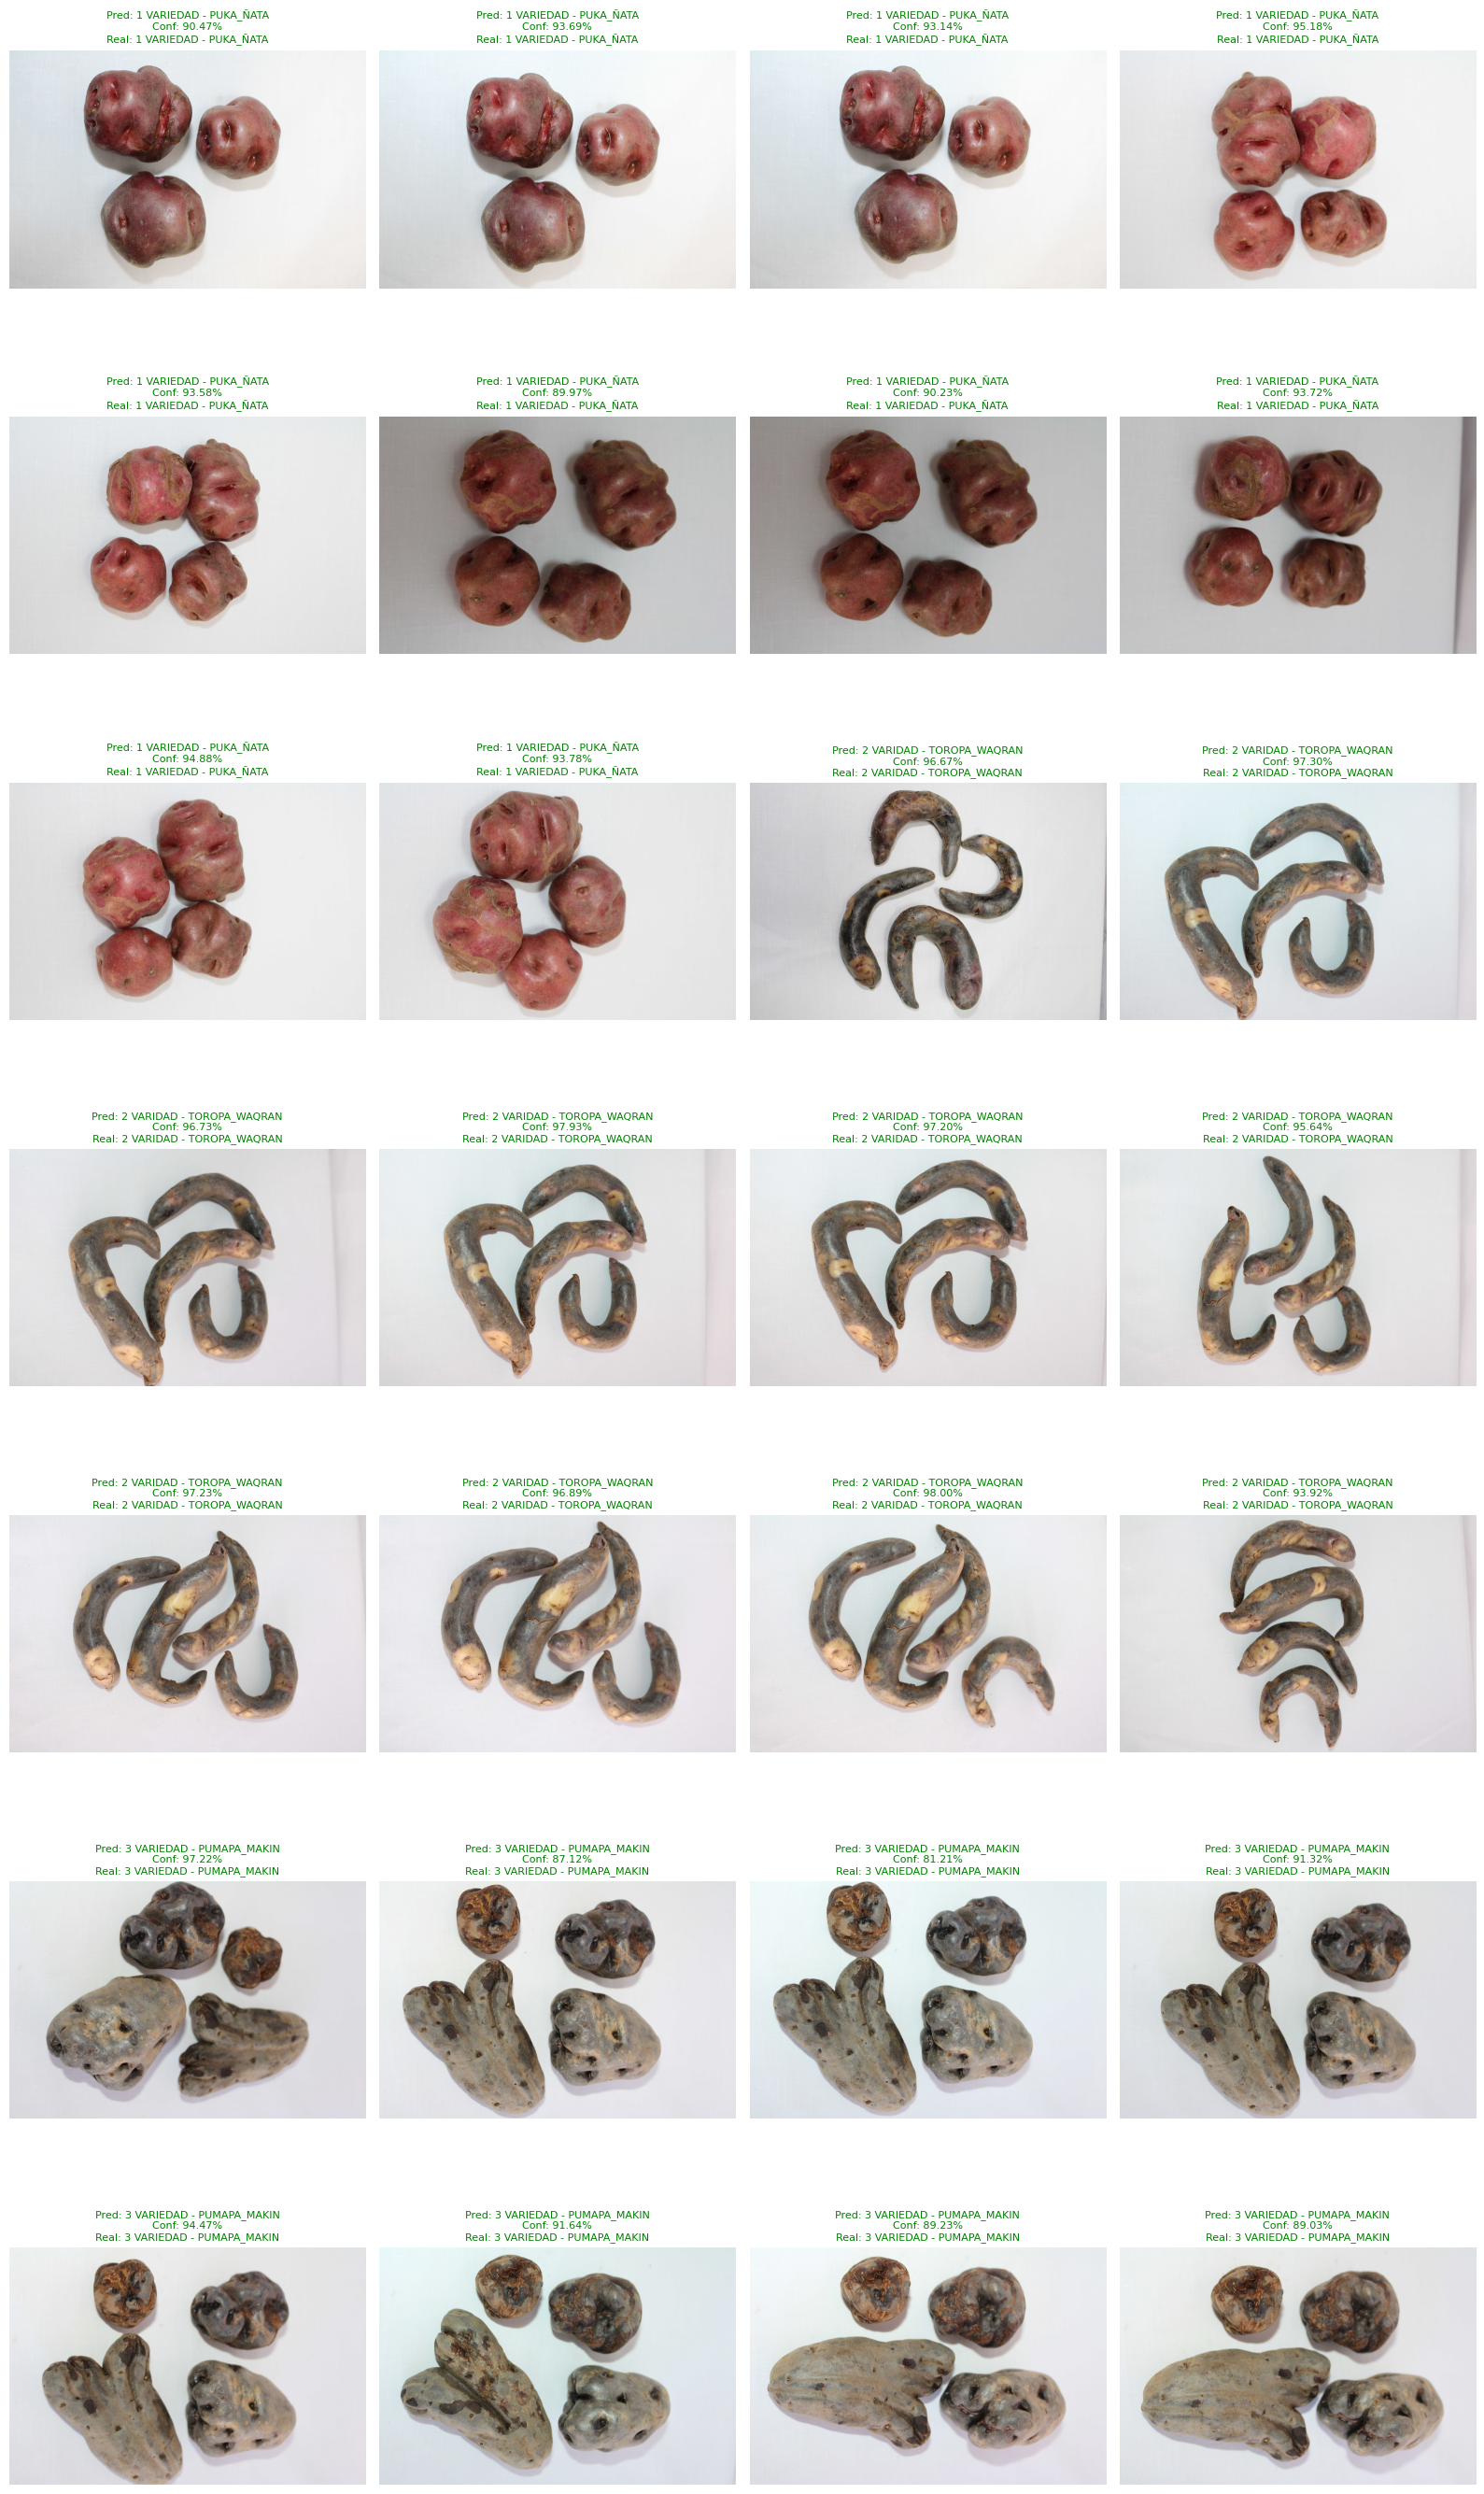

Grid guardado en: /kaggle/working/tomas_training/outputs_cnn_dataset_combinado/pruebas_imagenes_reales_cnn/grid_predicciones_imagenes_reales_cnn.png


In [13]:
# Prueba profesional con imágenes reales propias - CNN
# Esta celda CARGA el modelo entrenado desde disco antes de predecir.
TRAINED_CNN_MODEL_PATH = None  # opcional: Path("/kaggle/input/mi-modelo/clasificador_papas_cnn_final.keras")
FORCE_RELOAD_TRAINED_MODEL = True
REAL_TEST_IMAGE_DIR = None  # ejemplo: Path("/kaggle/input/mis-papas-reales")
REAL_TEST_IMAGE_PATHS = []  # también puedes pegar rutas individuales aquí
MAX_REAL_TEST_IMAGES = 70
GRID_MAX_IMAGES = 28
CONFIDENCE_WARNING_THRESHOLD = 0.70

REAL_TEST_OUTPUT_DIR = OUTPUT_DIR / "pruebas_imagenes_reales_cnn"
REAL_TEST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def find_existing_model_path(candidates):
    for candidate in candidates:
        if candidate is None:
            continue
        path = Path(candidate)
        if path.exists():
            return path
    return None


def find_trained_cnn_model_path():
    candidates = []
    if TRAINED_CNN_MODEL_PATH is not None:
        candidates.append(Path(TRAINED_CNN_MODEL_PATH))
    for var_name in ["final_model_path", "best_model_path", "fine_model_path", "head_model_path"]:
        if var_name in globals():
            candidates.append(Path(globals()[var_name]))
    candidates.extend([
        MODEL_DIR / "clasificador_papas_cnn_final.keras",
        MODEL_DIR / "best_model_cnn_finetune.keras",
        MODEL_DIR / "best_model_cnn.keras",
        MODEL_DIR / "best_model_cnn_head.keras",
    ])
    found = find_existing_model_path(candidates)
    if found is not None:
        return found

    search_roots = []
    for root_name in ["OUTPUT_DIR", "WORK_ROOT", "MODEL_DIR"]:
        if root_name in globals() and Path(globals()[root_name]).exists():
            search_roots.append(Path(globals()[root_name]))
    if Path("/kaggle/input").exists():
        search_roots.append(Path("/kaggle/input"))
    if Path("/kaggle/working").exists():
        search_roots.append(Path("/kaggle/working"))

    patterns = ["clasificador_papas_cnn_final.keras", "best_model_cnn_finetune.keras", "best_model_cnn*.keras", "*.keras"]
    discovered = []
    for root in search_roots:
        for pattern in patterns:
            discovered.extend(root.rglob(pattern))
    discovered = sorted(set(discovered), key=lambda p: p.stat().st_mtime if p.exists() else 0, reverse=True)
    if discovered:
        return discovered[0]
    raise FileNotFoundError(
        "No se encontró un modelo CNN entrenado (.keras). Ejecuta primero el entrenamiento o define TRAINED_CNN_MODEL_PATH."
    )


def load_trained_cnn_model():
    path = find_trained_cnn_model_path()
    print(f"Cargando modelo CNN entrenado desde: {path}")
    loaded = tf.keras.models.load_model(str(path))
    print("Modelo CNN cargado correctamente.")
    return loaded, path


if FORCE_RELOAD_TRAINED_MODEL or "model" not in globals():
    model, loaded_cnn_model_path = load_trained_cnn_model()
else:
    loaded_cnn_model_path = find_trained_cnn_model_path()
    print(f"Usando modelo CNN ya cargado en memoria. Referencia en disco: {loaded_cnn_model_path}")

classes_path_candidates = [OUTPUT_DIR / "classes.txt"]
if "WORK_ROOT" in globals():
    classes_path_candidates.append(Path(WORK_ROOT) / "outputs_cnn" / "classes.txt")
classes_path = find_existing_model_path(classes_path_candidates)
if classes_path is not None:
    loaded_classes = classes_path.read_text(encoding="utf-8").splitlines()
    if loaded_classes and loaded_classes != class_names:
        print("Advertencia: classes.txt no coincide exactamente con class_names en memoria. Se usará class_names del notebook.")


def is_real_image_path(path):
    text = str(path)
    return Path(path).suffix.lower() in VALID_EXTENSIONS and "__sd_img2img_synthetic_1000" not in text


def infer_label_from_path(path):
    parts_norm = [normalize_key(part) for part in Path(str(path)).parts]
    for idx, class_name in enumerate(class_names):
        if normalize_key(class_name) in parts_norm:
            return idx, class_name
    return None, None


def collect_real_images_for_testing():
    rows = []
    if REAL_TEST_IMAGE_PATHS:
        for p in REAL_TEST_IMAGE_PATHS:
            p = Path(p)
            if p.exists() and is_real_image_path(p):
                label, label_name = infer_label_from_path(p)
                rows.append({"path": str(p), "true_label": label, "true_class": label_name, "source": "manual_paths"})
    elif REAL_TEST_IMAGE_DIR is not None:
        root = Path(REAL_TEST_IMAGE_DIR)
        if not root.exists():
            raise FileNotFoundError(f"No existe REAL_TEST_IMAGE_DIR: {root}")
        for p in sorted(root.rglob("*")):
            if p.is_file() and is_real_image_path(p):
                label, label_name = infer_label_from_path(p)
                rows.append({"path": str(p), "true_label": label, "true_class": label_name, "source": "custom_real_dir"})
    else:
        real_test_df = test_df[~test_df["path"].astype(str).str.contains("__sd_img2img_synthetic_1000", regex=False)].copy()
        if MAX_REAL_TEST_IMAGES is not None:
            per_class = max(1, int(np.ceil(MAX_REAL_TEST_IMAGES / max(NUM_CLASSES, 1))))
            real_test_df = real_test_df.groupby("class_name", group_keys=False).head(per_class).head(MAX_REAL_TEST_IMAGES)
        for _, row in real_test_df.iterrows():
            rows.append({"path": row["path"], "true_label": int(row["label"]), "true_class": row["class_name"], "source": "manifest_test_real"})
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No se encontraron imágenes reales para probar. Define REAL_TEST_IMAGE_DIR o REAL_TEST_IMAGE_PATHS.")
    return df.reset_index(drop=True)


def predict_real_images_cnn(real_df):
    records = []
    for _, row in real_df.iterrows():
        img = image.load_img(row["path"], target_size=(IMG_SIZE, IMG_SIZE))
        arr = image.img_to_array(img).astype("float32")
        probs = model.predict(np.expand_dims(arr, axis=0), verbose=0)[0]
        top_idx = np.argsort(probs)[::-1][:3]
        pred_label = int(top_idx[0])
        true_label = row.get("true_label", None)
        has_label = true_label is not None and not pd.isna(true_label)
        records.append({
            "path": row["path"],
            "file_name": Path(row["path"]).name,
            "source": row.get("source", "unknown"),
            "model_path": str(loaded_cnn_model_path),
            "true_label": true_label,
            "true_class": row.get("true_class", None),
            "pred_label": pred_label,
            "pred_class": class_names[pred_label],
            "confidence_top1": float(probs[pred_label]),
            "top2_class": class_names[int(top_idx[1])],
            "top2_confidence": float(probs[int(top_idx[1])]),
            "top3_class": class_names[int(top_idx[2])],
            "top3_confidence": float(probs[int(top_idx[2])]),
            "is_correct": None if not has_label else bool(pred_label == int(true_label)),
            "low_confidence": bool(float(probs[pred_label]) < CONFIDENCE_WARNING_THRESHOLD),
        })
    return pd.DataFrame(records)


def summarize_real_image_results(results_df, prefix="cnn"):
    results_path = REAL_TEST_OUTPUT_DIR / f"resultados_imagenes_reales_{prefix}.csv"
    results_df.to_csv(results_path, index=False, encoding="utf-8")
    labeled = results_df.dropna(subset=["true_label"]).copy()
    summary = {
        "modelo": prefix,
        "loaded_model_path": str(loaded_cnn_model_path),
        "n_images": len(results_df),
        "n_labeled": len(labeled),
        "mean_confidence_top1": float(results_df["confidence_top1"].mean()),
        "median_confidence_top1": float(results_df["confidence_top1"].median()),
        "low_confidence_count": int(results_df["low_confidence"].sum()),
    }
    if not labeled.empty:
        y_true_real = labeled["true_label"].astype(int).to_numpy()
        y_pred_real = labeled["pred_label"].astype(int).to_numpy()
        summary.update({
            "accuracy_labeled": float(accuracy_score(y_true_real, y_pred_real)),
            "balanced_accuracy_labeled": float(balanced_accuracy_score(y_true_real, y_pred_real)),
        })
        report_real = pd.DataFrame(classification_report(y_true_real, y_pred_real, labels=list(range(NUM_CLASSES)), target_names=class_names, output_dict=True, zero_division=0)).T
        report_real.to_csv(REAL_TEST_OUTPUT_DIR / f"classification_report_imagenes_reales_{prefix}.csv", encoding="utf-8")
    summary_df = pd.DataFrame([summary])
    summary_df.to_csv(REAL_TEST_OUTPUT_DIR / f"resumen_imagenes_reales_{prefix}.csv", index=False, encoding="utf-8")
    print(f"Resultados guardados en: {results_path}")
    display(summary_df)
    display(results_df.sort_values("confidence_top1").head(15))
    return summary_df


def plot_real_image_predictions(results_df, prefix="cnn", max_images=GRID_MAX_IMAGES):
    plot_df = results_df.head(max_images).copy()
    cols = 4
    rows = int(np.ceil(len(plot_df) / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for i, (_, row) in enumerate(plot_df.iterrows(), 1):
        img = Image.open(row["path"]).convert("RGB")
        ax = plt.subplot(rows, cols, i)
        ax.imshow(img)
        ok = row.get("is_correct", None)
        color = "black" if pd.isna(ok) else "green" if bool(ok) else "red"
        title = f"Pred: {row['pred_class']}\nConf: {row['confidence_top1']:.2%}"
        if row.get("true_class") is not None and not pd.isna(row.get("true_class")):
            title += f"\nReal: {row['true_class']}"
        ax.set_title(title, color=color, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    out_path = REAL_TEST_OUTPUT_DIR / f"grid_predicciones_imagenes_reales_{prefix}.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Grid guardado en: {out_path}")

real_images_df = collect_real_images_for_testing()
real_results_cnn = predict_real_images_cnn(real_images_df)
real_summary_cnn = summarize_real_image_results(real_results_cnn, "cnn")
plot_real_image_predictions(real_results_cnn, "cnn")

In [14]:
import base64
from IPython.display import Javascript, display

# 1. Crear el archivo ZIP
shutil.make_archive('/kaggle/working/tomas_training', 'zip', '/kaggle/working/')

'/kaggle/working/tomas_training.zip'